Complete Workflow for generating ATS input for Coweeta

This workflow provides a complete working example to develop a simulation campaign for integrated hydrology within ATS.  

It uses the following datasets:

* `NHD Plus` for hydrography.
* `3DEP` for elevation
* `NLCD` for land cover/transpiration/rooting depths
* `MODIS` for LAI
* `GLYHMPS` geology data for structural formations
* `Pelletier` for depth to bedrock and soil texture information
* `SSURGO` for soil data, where available, in the top 2m.

Given some basic inputs (in the next cell) including a NAME, this workflow creates the following files, all of which will reside in output_data:

* Mesh file: `gcrew-atselm.exo`, includes all labeled sets
* Forcing: aorc data -- daily raster of precip, RH, incoming radiation, etc.
  - `gcrew-atselm_aorc_2010_2012.h5`, the DayMet data on this watershed
  - `gcrew-atselm_aorc_CyclicSteadystate.h5`, a "typical year" of DayMet, smoothed for spinup purposes, then looped certain number of years
* Forcing: LAI data -- every 4 days, time series by land cover type of LAI.
  - `gcrew-atselm_LAI_MODIS_transient.h5`, the LAI, interpolated and smoothed from the raw MODIS data
  - `gcrew-atselm_LAI_MODIS_CyclicSteadystate.h5`, a "typical year" of LAI, smoothed for spinup purposes then looped 10 years
* ATS Input files for three runs, intended to be run sequentially:
  - `gcrew-atselm_steadystate.xml` the steady-state solution based on uniform application of mean rainfall rate
  - `gcrew-atselm_cyclic_steadystate.xml` the cyclic steady state based on typical years
  - `gcrew-atselm_transient.xml` the forward model, run from 2010 -- 2011

* ELM Input files:
  - `domain.lnd.NGRIDx1pt_gcrew-atselm.nc`, the surface domain file for running ELM.
  - `surfdata_NGRIDx1pt_simyr1850_c240308_gcrew-atselm.nc`
  - `landuse.timeseries_NGRIDx1pt_hist_simyr1850-2015_c240308_gcrew-atselm.nc`
  - `cpl_bypass_full/ATS-subdaily_*.nc`

In [1]:
# these can be turned on for development work
%load_ext autoreload
%autoreload 2

In [2]:
## FIX ME -- why is this broken without importing netcdf first?
import netCDF4

In [3]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [4]:
import os,sys
import logging
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm as pcm
import shapely
import pandas as pd
import geopandas as gpd
import cftime, datetime
pd.options.display.max_columns = None

import shutil

## provide paths to relevant packages for mesh and input file generation 
# Set paths to relevant packages for mesh and input file generation
# Update these paths to match your local installation
#
sys.path.append('/Users/f9y/micromamba/amanzi-ats-tools/seacas-exodus/lib')
#sys.path.append('/Users/f9y/ATS_ROOT/INSTALLED/mpich-4.x/amanzi-tpls-Debug-0.98.13/SEACAS/lib')
%set_env AMANZI_SRC_DIR=/Users/f9y/mygithub/ATS_REPOS/amanzi
%set_env ATS_SRC_DIR=/Users/f9y/mygithub/ATS_REPOS/amanzi/src/physics/ats
%set_env DIN_LOC_ROOT=/Users/f9y/e3sm_inputdata
sys.path.append('/Users/f9y/micromamba/amanzi-ats-tools/amanzi_xml')


import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.meteorology
import watershed_workflow.land_cover_properties
import watershed_workflow.resampling
import watershed_workflow.condition
import watershed_workflow.io
import watershed_workflow.sources.standard_names as names
import watershed_workflow.elm_domain as elm_domain

import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io

import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors

#-------------------------------------------------------------------------------------
#--- options for using ELM soil column layer structure
ELM_SOILCOLUMN=True
# by default, ELM soil layer number is 15. If  option true, it's 30
# and ELM namelist flag: more_vertlayers = .true.
MORE_VERTLAYERS=False
if ELM_SOILCOLUMN:
    import watershed_workflow.elm_domain as elm_domain
    import watershed_workflow.elm_mksrfdata as elm_mksrfdata
    from types import SimpleNamespace
    import watershed_workflow.elm_metdata as elm_metdata
    # e3sm has a xml file, in which by machine-name, DIN_LOC_ROOT is pre-defined.
    # (TODO this locally or from data server)
    DIN_LOC_ROOT = '/Users/f9y/e3sm_inputdata'
    elm_domain.set_e3sm_input(DIN_LOC_ROOT)

#-------------------------------------------------------------------------------------

# set the default figure size for notebooks
plt.rcParams["figure.figsize"] = (8, 6)


print(watershed_workflow.__file__)

env: AMANZI_SRC_DIR=/Users/f9y/mygithub/ATS_REPOS/amanzi
env: ATS_SRC_DIR=/Users/f9y/mygithub/ATS_REPOS/amanzi/src/physics/ats
env: DIN_LOC_ROOT=/Users/f9y/e3sm_inputdata
/Users/f9y/mygithub/ATS_REPOS/watershed-workflow/watershed_workflow/__init__.py


## Input: Parameters and other source data

Note, this section will need to be modified for other runs of this workflow in other regions.

In [5]:
# Force Watershed Workflow to pull data from this directory rather than a shared data directory.
# This picks up the Coweeta-specific datasets set up here to avoid large file downloads for 
# demonstration purposes.
#
def splitPathFull(path):
    """
    Splits an absolute path into a list of components such that
    os.path.join(*splitPathFull(path)) == path
    """
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:  # root on Unix or drive letter with backslash on Windows (e.g., C:\)
            parts.insert(0, head)
            break
        elif tail == path:  # just a single file or directory
            parts.insert(0, tail)
            break
        else:
            parts.insert(0, tail)
            path = head
    return parts

cwd = splitPathFull(os.getcwd())

# REMOVE THIS PORTION OF THE CELL for general use outside of Coweeta -- this is just locating 
# the working directory within the WW directory structure
wkdir_name='GCREW'
if cwd[-1] == wkdir_name:
    pass
elif cwd[-1] == 'examples':
    cwd.append(wkdir_name)
else:
    cwd.extend(['examples',wkdir_name])
# END REMOVE THIS PORTION

# Note, this directory is where downloaded data will be put as well
data_dir = os.path.join(*(cwd + ['input_data',]))
def toInput(filename):
    return os.path.join(data_dir, filename)

output_dir = os.path.join(*(cwd + ['output_data',]))
def toOutput(filename):
    return os.path.join(output_dir, filename)

work_dir = os.path.join(*cwd)
def toWorkingDir(filename):
    return os.path.join(work_dir, filename)
       

In [6]:
# Set the data directory to the local space to get the locally downloaded files
# REMOVE THIS CELL for general use outside fo Coweeta
watershed_workflow.config.setDataDirectory(data_dir)


In [7]:
## Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed. 
myname = wkdir_name.lower()+'-atselm'
mycase_shapefile = os.path.join('input_data', 'gcrew_basin31.shp')

# Geometric parameters
# -- parameters to clean and reduce the river network prior to meshing
simplify = 10                   # length scale to target average edge 
ignore_small_rivers = 2         # remove rivers with fewer than this number of reaches -- important for NHDPlus HR 
prune_by_area_fraction = 0.01   # prune any reaches whose contributing area is less than this fraction of the domain

# -- mesh triangle refinement control
refine_d0 = 100
refine_d1 = 300

#refine_L0 = 75
#refine_L1 = 200

refine_L0 = 40
refine_L1 = 100

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

# Simulation control
# - note that we use the NoLeap calendar, same as DayMet.  Simulations are typically run over the "water year"
#   which starts August 1.
start = cftime.DatetimeNoLeap(2003,1,1)   # modis LAI starts from 2002-07-04
end = cftime.DatetimeNoLeap(2022,1,1)   # ROAC v1.1 met data ends by 2021-12-31 

nyears_cyclic_steadystate = 4   # how many years to run spinup

# Global Soil Properties
min_porosity = 0.05 # minimum porosity considered "too small"
max_permeability = 1.e-10 # max value considered "too permeable"
max_vg_alpha = 1.e-3 # max value of van Genuchten's alpha -- our correlation is not valid for some soils



In [8]:
# a dictionary of output_filenames -- will include all filenames generated
output_filenames = {}

In [9]:
# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.default_crs

In [10]:
# get the shape and crs of the shape
mycase_source = watershed_workflow.sources.ManagerShapefile(mycase_shapefile)
mycase = mycase_source.getShapes(out_crs=crs)
mycase.rename(columns={'AREA' : names.AREA}, inplace=True)


2025-12-13 11:56:18,700 - root - INFO: fixing column: geometry


In [11]:
# set up a dictionary of source objects
#
# Data sources, also called managers, deal with downloading and parsing data files from a variety of online APIs.
sources = watershed_workflow.sources.getDefaultSources()
sources['hydrography'] = watershed_workflow.sources.hydrography_sources['NHDPlus HR']

#
# This demo uses a few datasets that have been clipped out of larger, national
# datasets and are distributed with the code.  This is simply to save download
# time for this simple problem and to lower the barrier for trying out
# Watershed Workflow.  A more typical workflow would delete these lines (as 
# these files would not exist for other watersheds).
#
# The default versions of these download large raster and shapefile files that
# are defined over a very large region (globally or the entire US).
#
# DELETE THIS SECTION for non-Coweeta runs
dtb_file = os.path.join(data_dir, 'soil_structure', 'DTB', 'DTB.tif')
if ELM_SOILCOLUMN:
    dtb_file = os.path.join(DIN_LOC_ROOT, 'lnd/clm2/surfdata_map','high_res','soildtb_30x30sec_nwh_c220613.tif')

geo_file = os.path.join(data_dir, 'soil_structure', 'GLHYMPS', 'GLHYMPS.shp')

# GLHYMPs is a several-GB download, so we have sliced it and included the slice here
sources['geologic structure'] = watershed_workflow.sources.ManagerGLHYMPS(geo_file)

# The Pelletier DTB map is not particularly accurate at Coweeta -- the SoilGrids map seems to be better.
# Here we will use a clipped version of that map.
sources['depth to bedrock'] = watershed_workflow.sources.ManagerRaster(dtb_file)

# END DELETE THIS SECTION

# log the sources that will be used here
watershed_workflow.sources.logSources(sources)


2025-12-13 11:56:21,719 - root - INFO: Using sources:
2025-12-13 11:56:21,720 - root - INFO: --------------
2025-12-13 11:56:21,720 - root - INFO: HUC: WBD
2025-12-13 11:56:21,720 - root - INFO: hydrography: NHDPlus HR
2025-12-13 11:56:21,721 - root - INFO: DEM: 3DEP 10m
2025-12-13 11:56:21,721 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2025-12-13 11:56:21,721 - root - INFO: geologic structure: shapefile: "GLHYMPS.shp"
2025-12-13 11:56:21,721 - root - INFO: land cover: NLCD 2021 L48
2025-12-13 11:56:21,721 - root - INFO: LAI: MODIS
2025-12-13 11:56:21,722 - root - INFO: depth to bedrock: raster: "soildtb_30x30sec_nwh_c220613.tif"
2025-12-13 11:56:21,722 - root - INFO: meteorology: AORC v1.1


## Basin Geometry

In this section, we choose the basin, the streams to be included in the stream-aligned mesh, and make sure that all are resolved discretely at appropriate length scales for this work.

### the Watershed

2025-12-13 11:56:26,618 - root - INFO: Removing holes on 1 polygons
2025-12-13 11:56:26,619 - root - INFO:   -- removed interior
2025-12-13 11:56:26,620 - root - INFO:   -- union
2025-12-13 11:56:26,620 - root - INFO: Parsing 1 components for holes
2025-12-13 11:56:26,621 - root - INFO:   -- complete


<Axes: >

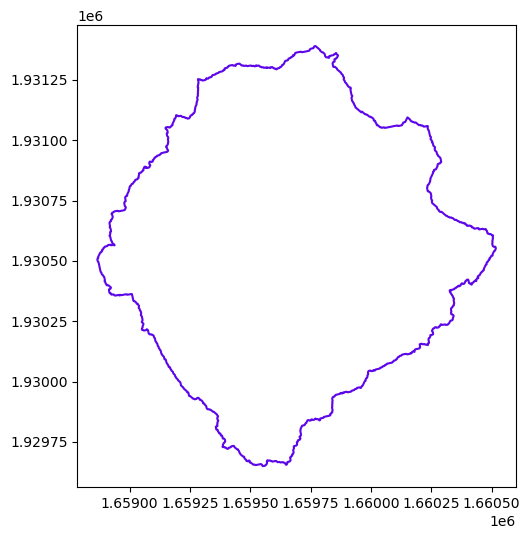

In [12]:
# Construct and plot the WW object used for storing watersheds
watershed = watershed_workflow.split_hucs.SplitHUCs(mycase)
watershed.plot()

### the Rivers 

In [13]:
# download/collect the river network within that shape's bounds
reaches = sources['hydrography'].getShapesByGeometry(watershed.exterior, crs, out_crs=crs)
# reach 0 is cross a road, which out of bounds. Drop it manually
reaches=reaches.drop(0)
rivers = watershed_workflow.river_tree.createRivers(reaches, method='hydroseq')

watershed_orig, rivers_orig = watershed, rivers

2025-12-13 11:56:34,029 - root - INFO: fixing column: geometry
2025-12-13 11:56:34,050 - root - INFO: fixing column: catchment


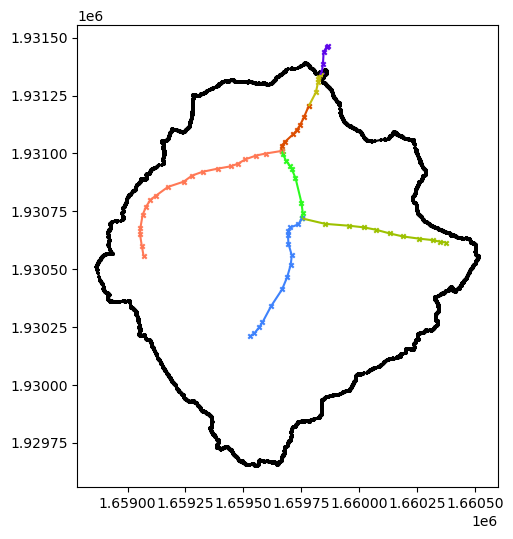

In [14]:
# plot the rivers and watershed
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1)
    ws.plot(color='k', marker='+', markersize=10, ax=ax)
    for river in rivs:
        river.plot(marker='x', markersize=10, ax=ax)

plot(watershed, rivers)

In [15]:
# keeping the originals for plotting comparisons
def createCopy(watershed, rivers):
    """To compare before/after, we often want to create copies.  Note in real workflows most things are done in-place without copies."""
    return watershed.deepcopy(), [r.deepcopy() for r in rivers]
    

2025-12-13 11:56:41,504 - root - INFO: 
2025-12-13 11:56:41,504 - root - INFO: Simplifying
2025-12-13 11:56:41,504 - root - INFO: ------------------------------
2025-12-13 11:56:41,505 - root - INFO: EPSG:5070
2025-12-13 11:56:41,505 - root - INFO: Presimplify to remove colinear, coincident points.
2025-12-13 11:56:41,508 - root - INFO: EPSG:5070
2025-12-13 11:56:41,508 - root - INFO: Pruning leaf reaches < 40
2025-12-13 11:56:41,508 - root - INFO: EPSG:5070
2025-12-13 11:56:41,508 - root - INFO: Merging internal reaches < 40
2025-12-13 11:56:41,509 - root - INFO: EPSG:5070
2025-12-13 11:56:41,510 - root - INFO:   reach: min seg length: 	    5.0036308153 	min geom length: 	  133.9467799957
2025-12-13 11:56:41,510 - root - INFO:   reach: med seg length: 	   39.5202102929 	med geom length: 	  310.0036742136
2025-12-13 11:56:41,510 - root - INFO:   reach: max seg length: 	  110.2607683058 	max geom length: 	  869.2432473425
2025-12-13 11:56:41,510 - root - INFO: 
2025-12-13 11:56:41,511 -

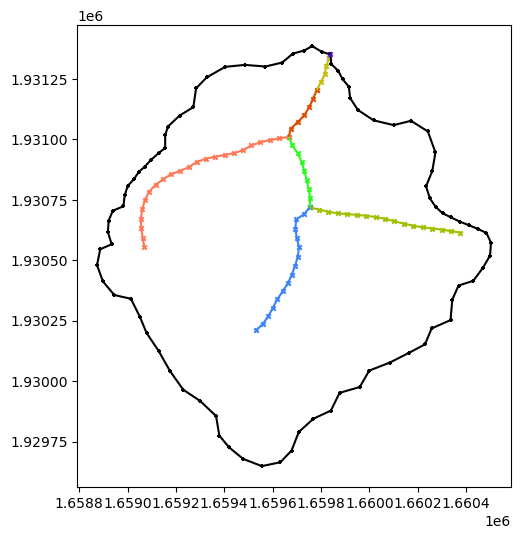

In [16]:
watershed, rivers = createCopy(watershed_orig, rivers_orig)

watershed_workflow.simplify(watershed, rivers, refine_L0, refine_L1, refine_d0, refine_d1)

# simplify may remove reaches from the rivers object
# -- this call removes any reaches from the dataframe as well, signaling we are all done removing reaches
#
# ETC: NOTE -- can this be moved into the simplify call?
for river in rivers:
    river.resetDataFrame()

plot(watershed, rivers)

In [17]:
# Now that the river network is set, find the watershed boundary outlets
for river in rivers:
    watershed_workflow.hydrography.findOutletsByCrossings(watershed, river)

2025-12-13 11:56:42,753 - root - INFO: Crossings by Polygon:
2025-12-13 11:56:42,753 - root - INFO:   Polygon 0
2025-12-13 11:56:42,753 - root - INFO:     crossing: [1659838.46247052 1931351.48620404]
2025-12-13 11:56:42,754 - root - INFO: Constructing outlet list
2025-12-13 11:56:42,754 - root - INFO: Iteration = 0
2025-12-13 11:56:42,754 - root - INFO: -----------------
2025-12-13 11:56:42,754 - root - INFO:  poly outlet 0 : 0, [1659838.46247052 1931351.48620404]
2025-12-13 11:56:42,754 - root - INFO: last outlet is 0 in polygon 0 at {crossings_clusters_centroids[last_outlet]}


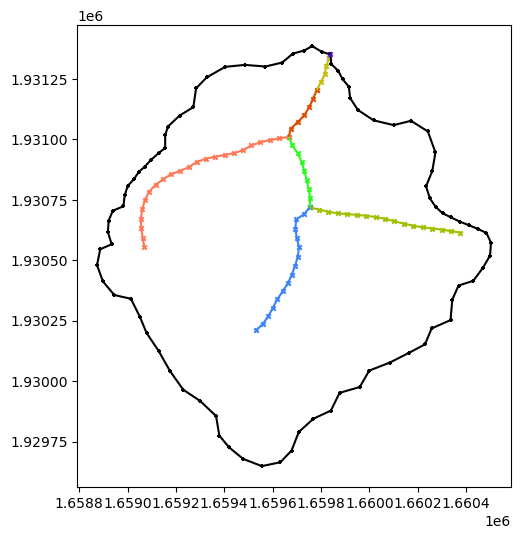

In [18]:
plot(watershed, rivers)

In [19]:
# this generates a zoomable map, showing different reaches and watersheds, 
# with discrete points.  Problem areas are clickable to get IDs for manual
# modifications.
m = watershed.explore(marker=False)
for river in rivers_orig:
    m = river.explore(m=m, column=None, color='black', name=river['name']+' raw', marker=False)
for river in rivers:
    m = river.explore(m=m)
    
m = watershed_workflow.makeMap(m)
m

### Mesh Geometry

Discretely create the stream-aligned mesh.  Download elevation data, and condition the mesh discretely to make for better topography.

2025-12-13 11:56:50,693 - root - INFO: 
2025-12-13 11:56:50,694 - root - INFO: Stream-aligned Meshing
2025-12-13 11:56:50,694 - root - INFO: ------------------------------
2025-12-13 11:56:50,695 - root - INFO: Creating stream-aligned mesh...
2025-12-13 11:56:50,709 - root - INFO: Adjusting HUC to match reaches at outlet
2025-12-13 11:56:50,713 - root - INFO: 
2025-12-13 11:56:50,713 - root - INFO: Triangulation
2025-12-13 11:56:50,714 - root - INFO: ------------------------------
2025-12-13 11:56:50,736 - root - INFO: Triangulating...
2025-12-13 11:56:50,736 - root - INFO:    228 points and 229 facets
2025-12-13 11:56:50,737 - root - INFO:  checking graph consistency
2025-12-13 11:56:50,737 - root - INFO:  tolerance is set to 1.0
2025-12-13 11:56:50,738 - root - INFO:  building graph data structures
2025-12-13 11:56:50,738 - root - INFO:  triangle.build...
2025-12-13 11:56:56,754 - root - INFO:   ...built: 1027 mesh points and 1824 triangles
2025-12-13 11:56:56,754 - root - INFO: Plot

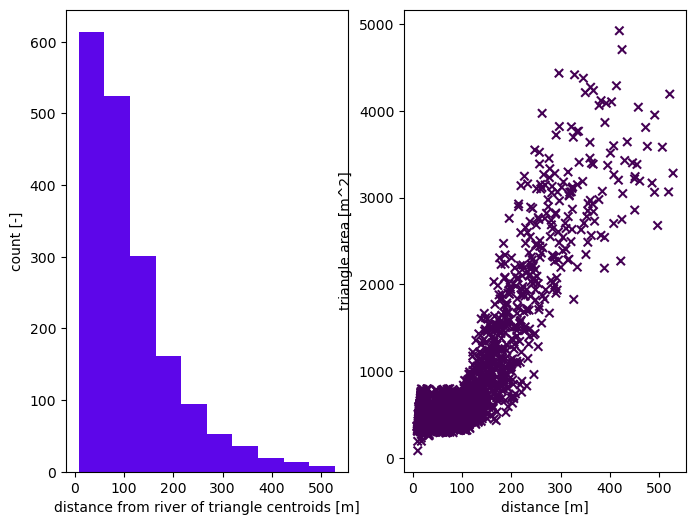

In [20]:
# Refine triangles if they get too acute
min_angle = 32 # degrees

# width of reach by stream order (order:width)
widths = dict({1:8,2:12,3:16,4:20})

# create the mesh
m2, areas, dists = watershed_workflow.tessalateRiverAligned(watershed, rivers, 
                                                            river_width=widths,
                                                            refine_min_angle=min_angle,
                                                            refine_distance=[refine_d0, refine_A0, refine_d1, refine_A1],
                                                            diagnostics=True)

In [21]:
# prepartition to maintain ordering
#m2 = m2.partition(640, True)

In [22]:
# get a raster for the elevation map, based on 3DEP
#dem = sources['DEM'].getDataset(watershed.exterior.buffer(50), watershed.crs)['dem']

# locally available raster DEM
dem_raster = os.path.join(data_dir,'topography','ned19_n39x00_w076x75_md_dnr_lidar2004_gcrew.tif') 
sources['DEM'] = watershed_workflow.sources.ManagerRaster(dem_raster)
dem = sources['DEM'].getDataset(watershed.exterior.buffer(50), watershed.crs)['band_1']
m2.cell_data['DEM'] = watershed_workflow.getDatasetOnMesh(m2, dem, method='linear')

# provide surface mesh elevations
watershed_workflow.elevate(m2, dem)

2025-12-13 11:57:15,793 - root - INFO: Incoming shape area = 0.00020077032794093506
2025-12-13 11:57:15,793 - root - INFO: ... buffering incoming shape by = 3.0864197867686016e-05
2025-12-13 11:57:15,794 - root - INFO: ... buffered shape area = 0.000202546755611303


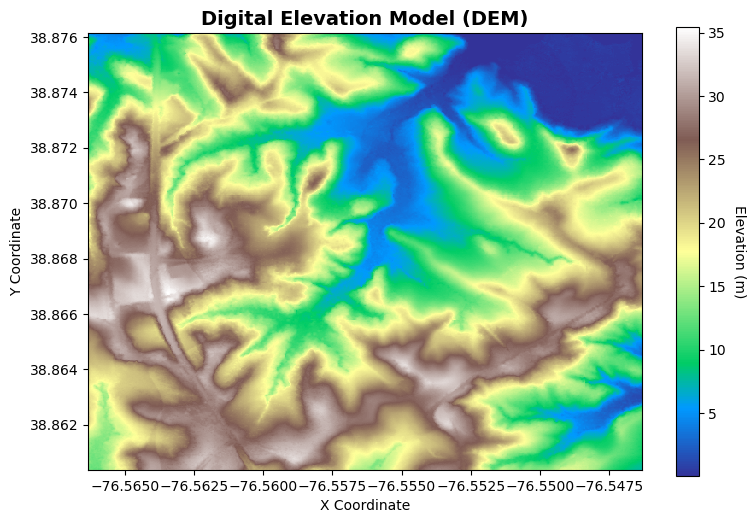

In [23]:
# Plot the DEM raster
fig, ax = plt.subplots()

# Plot the DEM data
im = dem.plot(ax=ax, cmap='terrain', add_colorbar=False)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Elevation (m)', rotation=270, labelpad=15)

# Add title and labels
ax.set_title('Digital Elevation Model (DEM)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')

# Set equal aspect ratio
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In the pit-filling algorithm, we want to make sure that river corridor is not filled up. Hence we exclude river corridor cells from the pit-filling algorithm.

In [24]:
# hydrologically condition the mesh, removing pits
river_mask=np.zeros((len(m2.conn)))
for i, elem in enumerate(m2.conn):
    if not len(elem)==3:
        river_mask[i]=1
watershed_workflow.condition.fillPitsDual(m2, is_waterbody=river_mask)

There are a range of options to condition river corridor mesh. We hydrologically condition the river mesh, ensuring unimpeded water flow in river corridors by globally adjusting flowlines to rectify artificial obstructions from inconsistent DEM elevations or misalignments. Please read the documentation for more information


2025-12-13 11:58:15,240 - matplotlib.axes._base - WARNING: Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


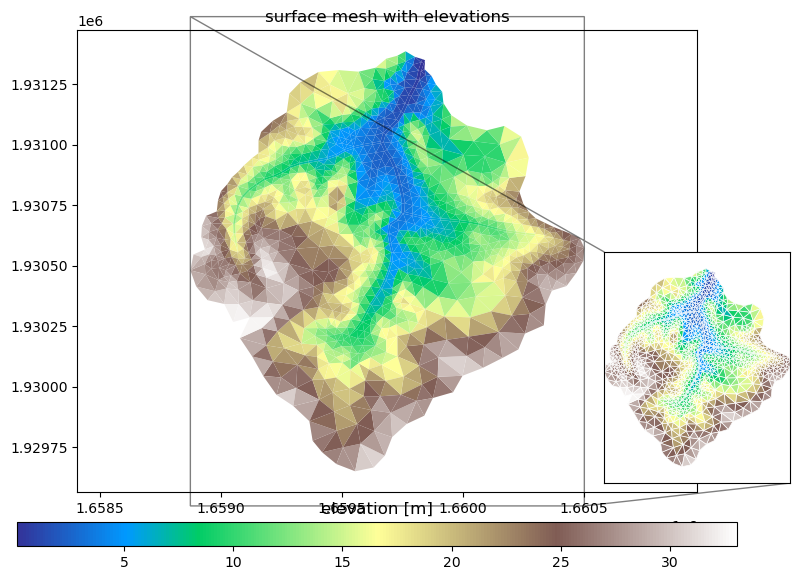

In [25]:
# conditioning river mesh
#
# adding elevations to the river tree for stream bed conditioning
watershed_workflow.condition.setProfileByDEM(rivers, dem)

# conditioning the river mesh using NHD elevations
watershed_workflow.condition.conditionRiverMesh(m2, rivers[0])

# plotting surface mesh with elevations
fig, ax = plt.subplots()
ax2 = ax.inset_axes([0.85,0.02,0.3,0.5])
cbax = fig.add_axes([0.05,0.02,0.9,0.04])

mp = m2.plot(facecolors='elevation', edgecolors=None, ax=ax, linewidth=0.5, colorbar=False)
cbar = fig.colorbar(mp, orientation="horizontal", cax=cbax)
ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')

mp2 = m2.plot(facecolors='elevation', edgecolors='white', ax=ax2, colorbar=False)
ax2.set_aspect('equal', 'datalim')

#xlim = (1.1322e6, 1.1328e6)
#ylim = (1.4085e6, 1.4088e6)
xlim = (np.min(m2.coords[:,0]), np.max(m2.coords[:,0]))
ylim = (np.min(m2.coords[:,1]), np.max(m2.coords[:,1]))

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_xticks([])
ax2.set_yticks([])

ax.indicate_inset_zoom(ax2, edgecolor='k')

cbar.ax.set_title('elevation [m]')

plt.show()


In [26]:
# add labeled sets for subcatchments and outlets
watershed_workflow.regions.addWatershedAndOutletRegions(m2, watershed, outlet_width=250, exterior_outlet=True)

# add labeled sets for river corridor cells
watershed_workflow.regions.addRiverCorridorRegions(m2, rivers)

# add labeled sets for river corridor cells by order
watershed_workflow.regions.addStreamOrderRegions(m2, rivers)

2025-12-13 11:58:50,977 - root - INFO: Adding regions for 1 polygons
2025-12-13 11:58:50,999 - root - INFO: Exterior outlet point (from attribute): POINT (1659838.462470521 1931351.4862040363)


In [27]:
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

10000 : CELL : 1895 : "0"
10001 : CELL : 1895 : "0 surface"
10002 : FACE : 86 : "0 boundary"
10003 : FACE : 14 : "0 outlet"
10004 : FACE : 13 : "surface domain outlet"
10005 : CELL : 72 : "river corridor 0 surface"
10006 : CELL : 19 : "stream order 2"
10007 : CELL : 53 : "stream order 1"


## Surface properties

Meshes interact with data to provide forcing, parameters, and more in the actual simulation.  Specifically, we need vegetation type on the surface to provide information about transpiration and subsurface structure to provide information about water retention curves, etc.

### NLCD for LULC

We'll start by downloading and collecting land cover from the NLCD dataset, and generate sets for each land cover type that cover the surface.  Likely these will be some combination of grass, deciduous forest, coniferous forest, and mixed.

In [28]:
# download the NLCD raster
nlcd = sources['land cover'].getDataset(watershed.exterior.buffer(100), watershed.crs)['cover']

# what land cover types did we get?
logging.info('Found land cover dtypes: {}'.format(nlcd.dtype))
logging.info('Found land cover types: {}'.format(set(list(nlcd.values.ravel()))))

2025-12-13 11:58:57,339 - root - INFO: Incoming shape area = 0.00023038470876436234
2025-12-13 11:58:57,339 - root - INFO: ... buffering incoming shape by = 0.00027
2025-12-13 11:58:57,340 - root - INFO: ... buffered shape area = 0.00024686917735083805
2025-12-13 11:58:57,385 - root - INFO: Found land cover dtypes: uint8
2025-12-13 11:58:57,385 - root - INFO: Found land cover types: {np.uint8(41), np.uint8(11), np.uint8(43), np.uint8(81), np.uint8(82), np.uint8(52), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(90), np.uint8(127), np.uint8(95)}


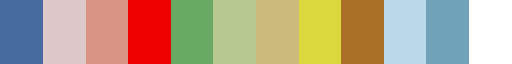

In [29]:
# create a colormap for the data
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
      watershed_workflow.colors.createNLCDColormap(np.unique(nlcd))
nlcd_cmap

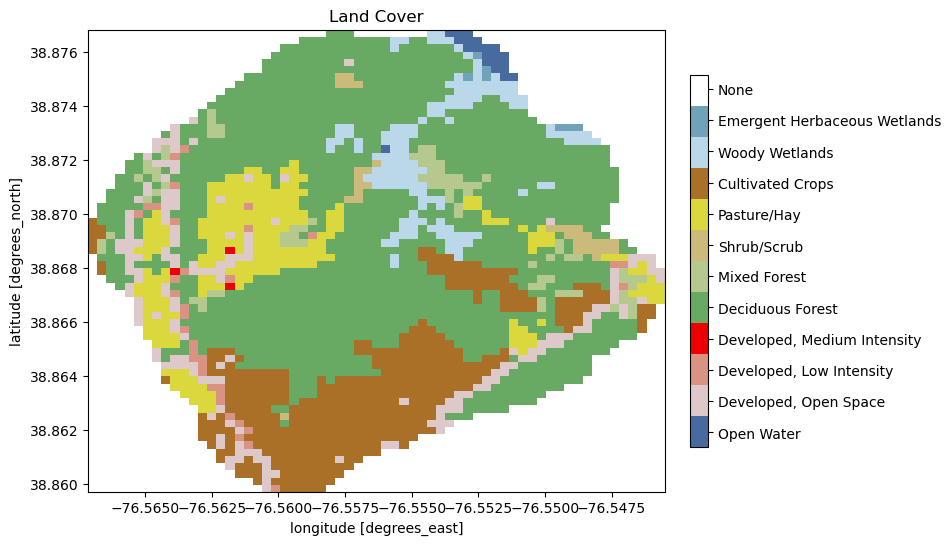

In [30]:
fig, ax = plt.subplots(1,1)
nlcd.plot.imshow(ax=ax, cmap=nlcd_cmap, norm=nlcd_norm, add_colorbar=False)
watershed_workflow.colors.createIndexedColorbar(ncolors=len(nlcd_indices), 
                               cmap=nlcd_cmap, labels=nlcd_labels, ax=ax) 
ax.set_title('Land Cover')
plt.show()

In [31]:
# map nlcd onto the mesh
m2_nlcd = watershed_workflow.getDatasetOnMesh(m2, nlcd, method='nearest')
m2.cell_data['land_cover'] = m2_nlcd



In [32]:
# double-check that nan not in the values
assert 127 not in m2_nlcd

# create a new set of labels and indices with only those that actually appear on the mesh
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
      watershed_workflow.colors.createNLCDColormap(np.unique(m2_nlcd))


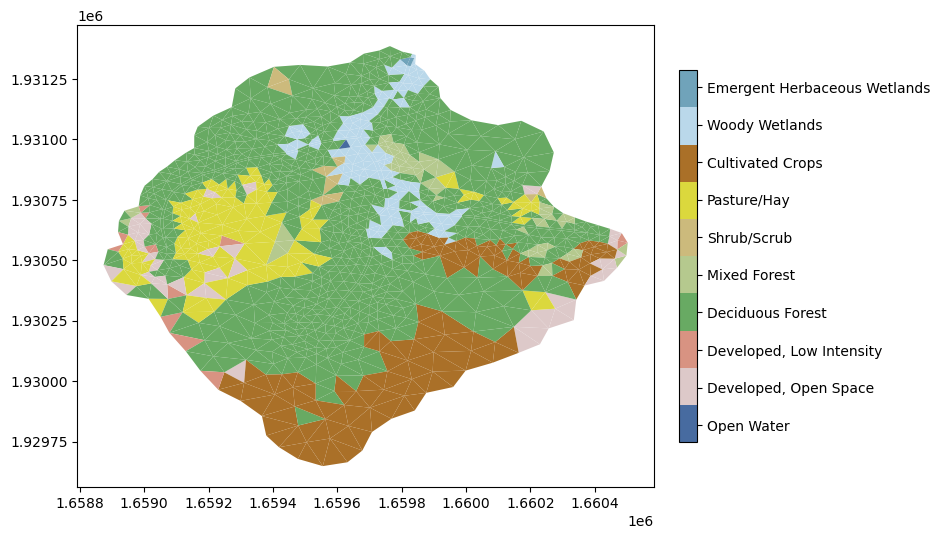

In [33]:
mp = m2.plot(facecolors=m2_nlcd, cmap=nlcd_cmap, norm=nlcd_norm, edgecolors=None, colorbar=False)
watershed_workflow.colors.createIndexedColorbar(ncolors=len(nlcd_indices), 
                               cmap=nlcd_cmap, labels=nlcd_labels, ax=plt.gca()) 
plt.show()

In [34]:
# add labeled sets to the mesh for NLCD
nlcd_labels_dict = dict(zip(nlcd_indices, nlcd_labels))
watershed_workflow.regions.addSurfaceRegions(m2, names=nlcd_labels_dict)

In [35]:
nlcd_labels_dict

{np.uint8(11): 'Open Water',
 np.uint8(21): 'Developed, Open Space',
 np.uint8(22): 'Developed, Low Intensity',
 np.uint8(41): 'Deciduous Forest',
 np.uint8(43): 'Mixed Forest',
 np.uint8(52): 'Shrub/Scrub',
 np.uint8(81): 'Pasture/Hay',
 np.uint8(82): 'Cultivated Crops',
 np.uint8(90): 'Woody Wetlands',
 np.uint8(95): 'Emergent Herbaceous Wetlands'}

In [36]:
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

10000 : CELL : 1895 : "0"
10001 : CELL : 1895 : "0 surface"
10002 : FACE : 86 : "0 boundary"
10003 : FACE : 14 : "0 outlet"
10004 : FACE : 13 : "surface domain outlet"
10005 : CELL : 72 : "river corridor 0 surface"
10006 : CELL : 19 : "stream order 2"
10007 : CELL : 53 : "stream order 1"
11 : CELL : 1 : "Open Water"
21 : CELL : 62 : "Developed, Open Space"
22 : CELL : 13 : "Developed, Low Intensity"
41 : CELL : 1205 : "Deciduous Forest"
43 : CELL : 69 : "Mixed Forest"
52 : CELL : 13 : "Shrub/Scrub"
81 : CELL : 188 : "Pasture/Hay"
82 : CELL : 152 : "Cultivated Crops"
90 : CELL : 191 : "Woody Wetlands"
95 : CELL : 2 : "Emergent Herbaceous Wetlands"


### MODIS LAI

Leaf area index is needed on each land cover type -- this is used in the Evapotranspiration calculation.

In [37]:
# download LAI and corresponding LULC datasets -- these are actually already downloaded, 
# as the MODIS AppEEARS API is quite slow
#
# Note that MODIS does NOT work with the noleap calendar, so we have to convert to actual dates first
start_leap = cftime.DatetimeGregorian(start.year, start.month, start.day)
end_leap = cftime.DatetimeGregorian(end.year, end.month, end.day)
res = sources['LAI'].getDataset(watershed.exterior, crs, start_leap, end_leap)


2025-12-13 11:59:07,048 - root - INFO: Incoming shape area = 0.0001725396723910857
2025-12-13 11:59:07,048 - root - INFO: ... buffering incoming shape by = 0.0045000000000000005
2025-12-13 11:59:07,049 - root - INFO: ... buffered shape area = 0.00047325521405686637
2025-12-13 11:59:07,049 - root - INFO: Building request for bounds: [np.float64(-76.5702), np.float64(38.8564), np.float64(-76.5424), np.float64(38.8802)]
2025-12-13 11:59:07,050 - root - INFO: ... requires files:
2025-12-13 11:59:07,050 - root - INFO:  ... /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/land_cover/MODIS/modis_LAI_01-01-2003_01-01-2022_38.8802x-76.5702_38.8564x-76.5424.nc
2025-12-13 11:59:07,051 - root - INFO:  ... /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/land_cover/MODIS/modis_LULC_01-01-2003_01-01-2022_38.8802x-76.5702_38.8564x-76.5424.nc
2025-12-13 11:59:07,051 - root - INFO: ... files exist locally.


In [38]:
modis_data = res
assert modis_data['LAI'].rio.crs is not None
print(modis_data['LULC'].rio.crs, modis_data['LULC'].dtype)


EPSG:4326 float64


In [39]:
# MODIS data comes with time-dependent LAI AND time-dependent LULC -- just take the mode to find the most common LULC
modis_data['LULC'] = watershed_workflow.data.computeMode(modis_data['LULC'], 'time_LULC')

# now it is safe to have only one time
modis_data = modis_data.rename({'time_LAI':'time'})

# remove leap day (366th day of any leap year) to match our Noleap Calendar
modis_data = watershed_workflow.data.filterLeapDay(modis_data)

/Users/f9y/mygithub/ATS_REPOS/watershed-workflow/watershed_workflow/data.py:242: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  mode_result = scipy.stats.mode(da.values, axis=time_axis, nan_policy='omit', keepdims=False)


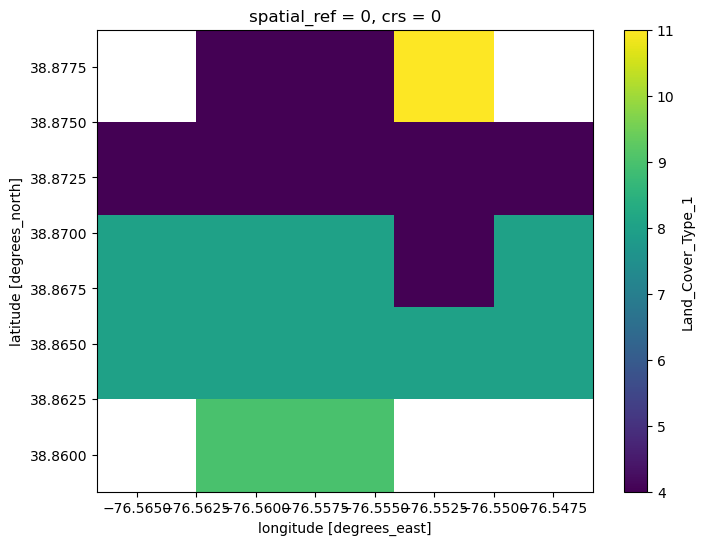

In [40]:
# plot the MODIS data -- note the entire domain is covered with one type for Coweeta (it is small!)
modis_data['LULC'].plot.imshow()

In [41]:
# compute the transient time series
modis_lai = watershed_workflow.land_cover_properties.computeTimeSeries(modis_data['LAI'], modis_data['LULC'], 
                                                                     polygon=watershed.exterior.buffer(100), polygon_crs=watershed.crs)

In [42]:
modis_lai

,Deciduous Broadleaf Forests LAI [-],Woody Savannas LAI [-],Savannas LAI [-],time
0,0.500,0.442857,0.3,2002-12-31 00:00:00
1,0.000,0.000000,0.0,2003-01-01 00:00:00
2,0.525,0.557143,0.3,2003-01-05 00:00:00
3,0.575,0.528571,0.5,2003-01-09 00:00:00
4,0.525,0.557143,0.4,2003-01-13 00:00:00
...,...,...,...,...
1741,0.700,0.671429,0.6,2021-12-15 00:00:00
1742,0.525,0.585714,0.3,2021-12-19 00:00:00
1743,0.650,0.742857,0.6,2021-12-23 00:00:00
1744,0.000,0.000000,0.0,2021-12-27 00:00:00


2025-12-13 11:59:11,800 - root - INFO: Writing HDF5 file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm_LAI_MODIS_transient.h5


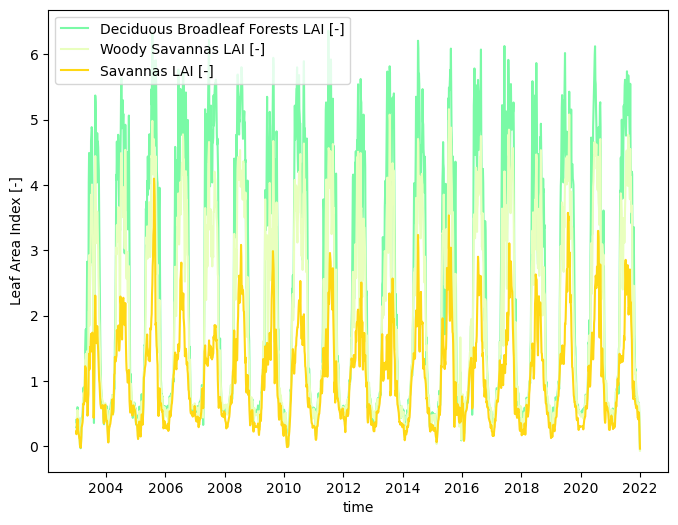

In [43]:
# smooth the data in time
modis_lai_smoothed = watershed_workflow.data.smoothTimeSeries(modis_lai, 'time')

# save the MODIS time series to disk
output_filenames['modis_lai_transient'] = toOutput(f'{myname}_LAI_MODIS_transient.h5')
watershed_workflow.io.writeTimeseriesToHDF5(output_filenames['modis_lai_transient'], modis_lai_smoothed)
watershed_workflow.land_cover_properties.plotLAI(modis_lai_smoothed, indices='MODIS')

2025-12-13 11:59:12,886 - root - INFO: Writing HDF5 file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm_LAI_MODIS_CyclicSteadystate.h5


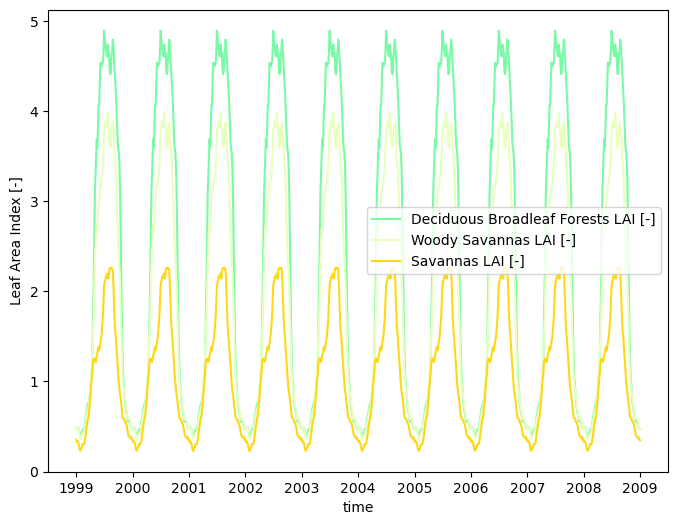

In [44]:
# compute a typical year
steadystate_td = datetime.timedelta(days=nyears_cyclic_steadystate*365)
modis_lai_typical = watershed_workflow.data.computeAverageYear(modis_lai_smoothed, start-steadystate_td, output_nyears=10)

output_filenames['modis_lai_cyclic_steadystate'] = toOutput(f'{myname}_LAI_MODIS_CyclicSteadystate.h5')
watershed_workflow.io.writeTimeseriesToHDF5(output_filenames['modis_lai_cyclic_steadystate'], modis_lai_typical)
watershed_workflow.land_cover_properties.plotLAI(modis_lai_typical, indices='MODIS')

### Crosswalk of LAI to NLCD LC

2025-12-13 11:59:15,280 - root - INFO: Compute the crosswalk between MODIS and NLCD:
2025-12-13 11:59:15,280 - root - INFO:   unique MODIS: [np.float64(4.0), np.float64(8.0), np.float64(9.0), np.float64(11.0)]
2025-12-13 11:59:15,281 - root - INFO:   unique NLCD: [np.uint8(11), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(41), np.uint8(43), np.uint8(52), np.uint8(81), np.uint8(82), np.uint8(90), np.uint8(95)]


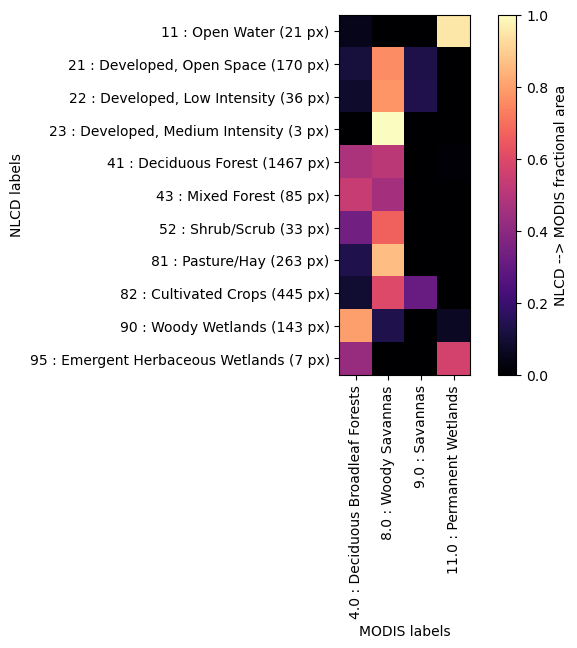

In [45]:
crosswalk = watershed_workflow.land_cover_properties.computeCrosswalk(modis_data['LULC'], nlcd, method='fractional area')

In [46]:
# Compute the NLCD-based time series
nlcd_lai_cyclic_steadystate = watershed_workflow.land_cover_properties.applyCrosswalk(crosswalk, modis_lai_typical)
nlcd_lai_transient = watershed_workflow.land_cover_properties.applyCrosswalk(crosswalk, modis_lai_smoothed)

watershed_workflow.land_cover_properties.removeNullLAI(nlcd_lai_cyclic_steadystate)
watershed_workflow.land_cover_properties.removeNullLAI(nlcd_lai_transient)
nlcd_lai_transient

None LAI [-] False
Open Water LAI [-] True
Perrenial Ice/Snow LAI [-] False
Developed, Medium Intensity LAI [-] True
Developed, High Intensity LAI [-] False
Barren Land LAI [-] False
None LAI [-] False
Open Water LAI [-] True
Perrenial Ice/Snow LAI [-] False
Developed, Medium Intensity LAI [-] True
Developed, High Intensity LAI [-] False
Barren Land LAI [-] False


,time,Open Water LAI [-],"Developed, Open Space LAI [-]","Developed, Low Intensity LAI [-]","Developed, Medium Intensity LAI [-]",Deciduous Forest LAI [-],Mixed Forest LAI [-],Shrub/Scrub LAI [-],Pasture/Hay LAI [-],Cultivated Crops LAI [-],Woody Wetlands LAI [-],Emergent Herbaceous Wetlands LAI [-]
0,2002-12-31 00:00:00,0.0,0.326336,0.323429,0.0,0.360985,0.368778,0.354904,0.341536,0.305399,0.362605,0.171173
1,2003-01-01 00:00:00,0.0,0.287177,0.286574,0.0,0.292661,0.294610,0.298639,0.302522,0.265324,0.268310,0.122449
2,2003-01-05 00:00:00,0.0,0.345619,0.345205,0.0,0.348046,0.350288,0.355272,0.360074,0.324987,0.318746,0.145408
3,2003-01-09 00:00:00,0.0,0.445315,0.443882,0.0,0.459771,0.465518,0.462302,0.459202,0.425811,0.437512,0.202551
4,2003-01-13 00:00:00,0.0,0.541598,0.539120,0.0,0.568676,0.577155,0.568424,0.560012,0.515912,0.549139,0.255612
...,...,...,...,...,...,...,...,...,...,...,...,...
1741,2021-12-15 00:00:00,0.0,0.644982,0.643519,0.0,0.658006,0.665106,0.664399,0.663718,0.618523,0.619595,0.285714
1742,2021-12-19 00:00:00,0.0,0.627103,0.626323,0.0,0.631634,0.636607,0.642404,0.647989,0.597346,0.583892,0.267347
1743,2021-12-23 00:00:00,0.0,0.460350,0.460847,0.0,0.450021,0.450924,0.464286,0.477159,0.436057,0.400500,0.180612
1744,2021-12-27 00:00:00,0.0,0.219268,0.220222,0.0,0.205174,0.203824,0.216071,0.227872,0.206619,0.172253,0.075765


In [47]:
# write the NLCD-based time series to disk
output_filenames['nlcd_lai_cyclic_steadystate'] = toOutput(f'{myname}_LAI_NLCD_CyclicSteadystate.h5')
watershed_workflow.io.writeTimeseriesToHDF5(output_filenames['nlcd_lai_cyclic_steadystate'], nlcd_lai_cyclic_steadystate)

output_filenames['nlcd_lai_transient'] = toOutput(f'{myname}_LAI_NLCD_{start.year}_{end.year}.h5')
watershed_workflow.io.writeTimeseriesToHDF5(output_filenames['nlcd_lai_transient'], nlcd_lai_transient)

2025-12-13 11:59:17,170 - root - INFO: Writing HDF5 file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm_LAI_NLCD_CyclicSteadystate.h5
2025-12-13 11:59:17,177 - root - INFO: Writing HDF5 file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm_LAI_NLCD_2003_2022.h5


## Subsurface Soil, Geologic Structure

### NRCS Soils

In [48]:
# get NRCS shapes, on a reasonable crs
nrcs = sources['soil structure'].getShapesByGeometry(watershed.exterior, watershed.crs, out_crs=crs)
nrcs

2025-12-13 11:59:29,968 - root - INFO: Attempting to download source for target '/Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/soil_structure/SSURGO/SSURGO_-76.5657_38.8609_-76.5469_38.8757.shp'
2025-12-13 11:59:29,976 - root - INFO:   Found 122 shapes.
2025-12-13 11:59:29,987 - root - INFO: found 19 unique MUKEYs.
2025-12-13 11:59:30,166 - root - INFO: Running Rosetta for van Genutchen parameters
2025-12-13 11:59:30,220 - root - INFO:   ... done
2025-12-13 11:59:30,221 - root - INFO:   requested 18 values
2025-12-13 11:59:30,221 - root - INFO:   got 18 responses
2025-12-13 11:59:30,226 - root - INFO: fixing column: geometry


,mukey,geometry,residual saturation [-],Rosetta porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],Rosetta permeability [m^2],thickness [m],permeability [m^2],porosity [-],bulk density [g/cm^3],total sand pct [%],total silt pct [%],total clay pct [%],source,ID,name
0,137713,"MULTIPOLYGON (((1659065.115 1929561.676, 16590...",0.201758,0.394111,0.000089,1.417257,2.271621e-13,1.812500,7.763941e-13,0.461420,1.427093,47.158057,35.713708,17.128235,NRCS,137713,NRCS-137713
1,137737,"MULTIPOLYGON (((1660563.272 1929931.566, 16605...",0.196063,0.404167,0.000158,1.445159,4.764437e-13,1.947500,1.121346e-12,0.453628,1.447885,68.198355,14.572973,17.228671,NRCS,137737,NRCS-137737
2,137738,"MULTIPOLYGON (((1659750.771 1929944.367, 16597...",0.195702,0.404127,0.000158,1.445741,4.781063e-13,1.953684,1.164453e-12,0.453942,1.447054,68.156365,14.703619,17.140016,NRCS,137738,NRCS-137738
3,137750,"POLYGON ((1660646.836 1929893.548, 1660635.372...",0.244692,0.397569,0.000064,1.375732,9.252928e-14,1.878000,4.923986e-13,0.442549,1.479410,29.279503,43.981715,26.738782,NRCS,137750,NRCS-137750
4,137753,"POLYGON ((1659220.871 1929832.167, 1659210.171...",0.204425,0.376594,0.000111,1.395992,1.930162e-13,1.858889,1.065512e-12,0.406623,1.514868,52.302644,30.979295,16.718061,NRCS,137753,NRCS-137753
5,137788,"MULTIPOLYGON (((1659189.97 1929588.567, 165920...",0.210305,0.382641,0.000145,1.391674,2.458269e-13,1.810000,1.231552e-12,0.421756,1.532347,62.425448,18.905372,18.669180,NRCS,137788,NRCS-137788
6,137789,"MULTIPOLYGON (((1659541.471 1929770.567, 16595...",0.213728,0.389838,0.000134,1.382418,2.337416e-13,1.820000,1.171899e-12,0.431732,1.505910,59.480100,20.596129,19.923771,NRCS,137789,NRCS-137789
7,137790,"MULTIPOLYGON (((1659555.792 1929653.951, 16595...",0.210308,0.383055,0.000121,1.385635,2.041080e-13,1.893000,9.747239e-13,0.430030,1.510420,55.450119,26.052274,18.497607,NRCS,137790,NRCS-137790
8,137791,"MULTIPOLYGON (((1659160.57 1929618.567, 165917...",0.212303,0.382054,0.000120,1.381680,1.921093e-13,1.893000,9.195966e-13,0.402168,1.515549,54.711466,26.467766,18.820768,NRCS,137791,NRCS-137791
9,137792,"POLYGON ((1659420.473 1930562.767, 1659407.973...",0.206610,0.379518,0.000129,1.391752,2.193591e-13,1.888000,1.021847e-12,0.425249,1.523091,57.778531,24.695931,17.525538,NRCS,137792,NRCS-137792


In [49]:
# create a clean dataframe with just the data we will need for ATS
def replace_column_nans(df, col_nan, col_replacement):
    """In a df, replace col_nan entries by col_replacement if is nan.  In Place!"""
    row_indexer = df[col_nan].isna()
    df.loc[row_indexer, col_nan] = df.loc[row_indexer, col_replacement]
    return

# where poro or perm is nan, put Rosetta poro
replace_column_nans(nrcs, 'porosity [-]', 'Rosetta porosity [-]')
replace_column_nans(nrcs, 'permeability [m^2]', 'Rosetta permeability [m^2]')

# drop unnecessary columns
for col in ['Rosetta porosity [-]', 'Rosetta permeability [m^2]']:
    nrcs.pop(col)
    
# drop nans
nan_mask = nrcs.isna().any(axis=1)
dropped_mukeys = nrcs.index[nan_mask]

# Drop those rows
nrcs = nrcs[~nan_mask]

assert nrcs['porosity [-]'][:].min() >= min_porosity
assert nrcs['permeability [m^2]'][:].max() <= max_permeability
nrcs

# check for nans
nrcs.isna().any()

mukey                          False
geometry                       False
residual saturation [-]        False
van Genuchten alpha [Pa^-1]    False
van Genuchten n [-]            False
thickness [m]                  False
permeability [m^2]             False
porosity [-]                   False
bulk density [g/cm^3]          False
total sand pct [%]             False
total silt pct [%]             False
total clay pct [%]             False
source                         False
ID                             False
name                           False
dtype: bool

In [50]:
# Compute the soil color of each cell of the mesh
# Note, we use mukey here because it is an int, while ID is a string
soil_color_mukey = watershed_workflow.getShapePropertiesOnMesh(m2, nrcs, 'mukey', 
                                                         resolution=50, nodata=-999)

nrcs.set_index('mukey', drop=False, inplace=True)

unique_soil_colors = list(np.unique(soil_color_mukey))
if -999 in unique_soil_colors:
    unique_soil_colors.remove(-999)

# retain only the unique values of soil_color
nrcs = nrcs.loc[unique_soil_colors]

# renumber the ones we know will appear with an ATS ID using ATS conventions
nrcs['ATS ID'] = range(1000, 1000+len(unique_soil_colors))
nrcs.set_index('ATS ID', drop=True, inplace=True)

# create a new soil color and a soil thickness map using the ATS IDs
soil_color = -np.ones_like(soil_color_mukey)
soil_tempv = np.nan * np.ones(soil_color.shape, 'd')

for v in ['thickness [m]','total sand pct [%]', 'total clay pct [%]']:
    if v not in nrcs.keys(): continue
    for ats_ID, ID, tempv in zip(nrcs.index, nrcs.mukey, nrcs[v]):
        mask = np.where(soil_color_mukey == ID)
        soil_tempv[mask] = tempv
        if 'soil_color' not in m2.cell_data.keys(): soil_color[mask] = ats_ID

    if 'soil_color' not in m2.cell_data.keys(): m2.cell_data['soil_color'] = soil_color
    m2.cell_data[v] = soil_tempv


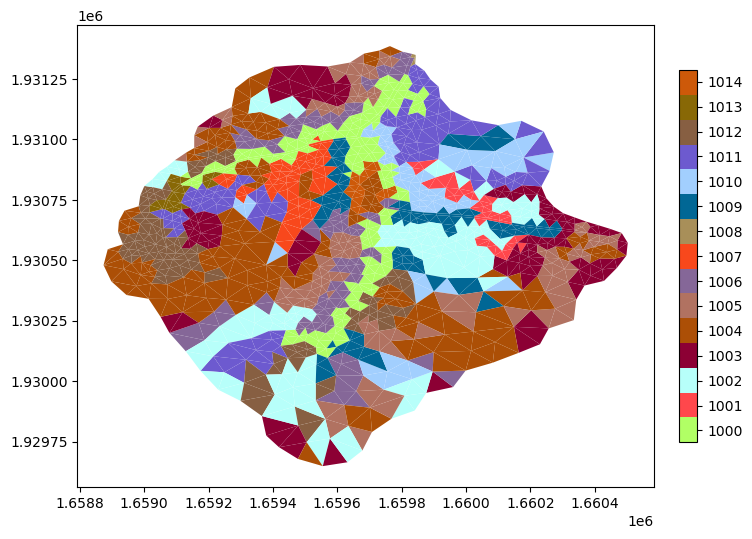

In [51]:
# plot the soil color
# -- get a cmap for soil color
sc_indices, sc_cmap, sc_norm, sc_ticks, sc_labels = \
      watershed_workflow.colors.createIndexedColormap(nrcs.index)

mp = m2.plot(facecolors=m2.cell_data['soil_color'], cmap=sc_cmap, norm=sc_norm, edgecolors=None, colorbar=False)
watershed_workflow.colors.createIndexedColorbar(ncolors=len(nrcs), 
                               cmap=sc_cmap, labels=sc_labels, ax=plt.gca()) 
plt.show()

### Depth to Bedrock from SoilGrids

In [52]:
dtb = sources['depth to bedrock'].getDataset(watershed.exterior, watershed.crs)['band_1']

# the SoilGrids dataset is in cm --> convert to meters
if not ELM_SOILCOLUMN: dtb.values = dtb.values/100.


2025-12-13 11:59:36,277 - root - INFO: Incoming shape area = 0.0001725396479945224
2025-12-13 11:59:36,278 - root - INFO: ... buffering incoming shape by = 0.008333333333325754
2025-12-13 11:59:36,279 - root - INFO: ... buffered shape area = 0.0008237203278378067


In [53]:
# map to the mesh
m2.cell_data['dtb'] = watershed_workflow.getDatasetOnMesh(m2, dtb, method='linear')


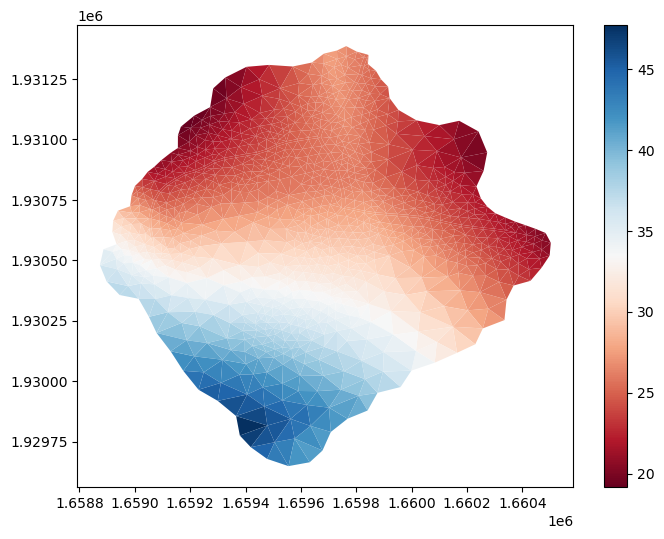

In [54]:
gons = m2.plot(facecolors=m2.cell_data['dtb'], cmap='RdBu', edgecolors=None)
plt.show()

### GLHYMPs Geology

In [55]:
glhymps = sources['geologic structure'].getShapesByGeometry(watershed.exterior.buffer(1000), watershed.crs, out_crs=crs)
glhymps = watershed_workflow.soil_properties.mangleGLHYMPSProperties(glhymps,
                                              min_porosity=min_porosity, 
                                              max_permeability=max_permeability, 
                                              max_vg_alpha=max_vg_alpha)

# intersect with the buffered geometry -- don't keep extras
glhymps = glhymps[glhymps.intersects(watershed.exterior.buffer(10))]
glhymps

2025-12-13 11:59:44,588 - root - INFO: fixing column: geometry


,ID,name,source,permeability [m^2],logk_stdev [-],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],geometry
0,922315,GLHYMPS-922315,GLHYMPS,1.000000e-13,2.0,0.22,0.000294,2.0,0.01,"MULTIPOLYGON (((1661665.546 1893067.866, 16615..."
1,922332,GLHYMPS-922332,GLHYMPS,1.000000e-13,2.0,0.22,0.000294,2.0,0.01,"POLYGON ((1656069.303 1936812.195, 1656135.688..."
2,922379,GLHYMPS-922379,GLHYMPS,1.258925e-11,1.2,0.28,0.001000,2.0,0.01,"MULTIPOLYGON (((1662145.566 1919512.522, 16620..."


In [56]:
# quality check -- make sure glymps shapes cover the watershed
print(glhymps.union_all().contains(watershed.exterior))
glhymps

True


,ID,name,source,permeability [m^2],logk_stdev [-],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],geometry
0,922315,GLHYMPS-922315,GLHYMPS,1.000000e-13,2.0,0.22,0.000294,2.0,0.01,"MULTIPOLYGON (((1661665.546 1893067.866, 16615..."
1,922332,GLHYMPS-922332,GLHYMPS,1.000000e-13,2.0,0.22,0.000294,2.0,0.01,"POLYGON ((1656069.303 1936812.195, 1656135.688..."
2,922379,GLHYMPS-922379,GLHYMPS,1.258925e-11,1.2,0.28,0.001000,2.0,0.01,"MULTIPOLYGON (((1662145.566 1919512.522, 16620..."


In [57]:
# clean the data
glhymps.pop('logk_stdev [-]')

assert glhymps['porosity [-]'][:].min() >= min_porosity
assert glhymps['permeability [m^2]'][:].max() <= max_permeability
assert glhymps['van Genuchten alpha [Pa^-1]'][:].max() <= max_vg_alpha

glhymps.isna().any()

ID                             False
name                           False
source                         False
permeability [m^2]             False
porosity [-]                   False
van Genuchten alpha [Pa^-1]    False
van Genuchten n [-]            False
residual saturation [-]        False
geometry                       False
dtype: bool

In [58]:
# note that for larger areas there are often common regions -- two labels with the same properties -- no need to duplicate those with identical values.
def reindex_remove_duplicates(df, index):
    """Removes duplicates, creating a new index and saving the old index as tuples of duplicate values. In place!"""
    if index is not None:
        if index in df:
            df.set_index(index, drop=True, inplace=True)

    index_name = df.index.name

    # identify duplicate rows
    duplicates = list(df.groupby(list(df)).apply(lambda x: tuple(x.index)))

    # order is preserved
    df.drop_duplicates(inplace=True)
    df.reset_index(inplace=True)
    df[index_name] = duplicates
    return

reindex_remove_duplicates(glhymps, 'ID')
glhymps

,ID,name,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],geometry
0,"(922315,)",GLHYMPS-922315,GLHYMPS,1.000000e-13,0.22,0.000294,2.0,0.01,"MULTIPOLYGON (((1661665.546 1893067.866, 16615..."
1,"(922332,)",GLHYMPS-922332,GLHYMPS,1.000000e-13,0.22,0.000294,2.0,0.01,"POLYGON ((1656069.303 1936812.195, 1656135.688..."
2,"(922379,)",GLHYMPS-922379,GLHYMPS,1.258925e-11,0.28,0.001000,2.0,0.01,"MULTIPOLYGON (((1662145.566 1919512.522, 16620..."


In [59]:
# Compute the geo color of each cell of the mesh
geology_color_glhymps = watershed_workflow.getShapePropertiesOnMesh(m2, glhymps, 'index', 
                                                         resolution=50, nodata=-999)

# retain only the unique values of geology that actually appear in our cell mesh
unique_geology_colors = list(np.unique(geology_color_glhymps))
if -999 in unique_geology_colors:
    unique_geology_colors.remove(-999)

# retain only the unique values of geology_color
glhymps = glhymps.loc[unique_geology_colors]

# renumber the ones we know will appear with an ATS ID using ATS conventions
glhymps['ATS ID'] = range(100, 100+len(unique_geology_colors))
glhymps['TMP_ID'] = glhymps.index
glhymps.reset_index(drop=True, inplace=True)
glhymps.set_index('ATS ID', drop=True, inplace=True)

# create a new geology color using the ATS IDs
geology_color = -np.ones_like(geology_color_glhymps)
for ats_ID, tmp_ID in zip(glhymps.index, glhymps.TMP_ID):
    geology_color[np.where(geology_color_glhymps == tmp_ID)] = ats_ID

glhymps.pop('TMP_ID')

m2.cell_data['geology_color'] = geology_color


In [60]:
geology_color_glhymps.min()

<xarray.DataArray 'index' ()> Size: 8B
array(0)

### Combine to form a complete subsurface dataset

## Extrude the 2D Mesh to make a 3D mesh

In [61]:
bedrock = watershed_workflow.soil_properties.getDefaultBedrockProperties()

# merge the properties databases
subsurface_props = pd.concat([glhymps, nrcs, bedrock])

# save the properties to disk for use in generating input file
output_filenames['subsurface_properties'] = toOutput(f'{myname}_subsurface_properties.csv')
subsurface_props.to_csv(output_filenames['subsurface_properties'])
subsurface_props


,ID,name,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],geometry,mukey,thickness [m],bulk density [g/cm^3],total sand pct [%],total silt pct [%],total clay pct [%]
100,"(922315,)",GLHYMPS-922315,GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,"MULTIPOLYGON (((1661665.546 1893067.866, 16615...",NaN,NaN,NaN,NaN,NaN,NaN
101,"(922332,)",GLHYMPS-922332,GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,"POLYGON ((1656069.303 1936812.195, 1656135.688...",NaN,NaN,NaN,NaN,NaN,NaN
102,"(922379,)",GLHYMPS-922379,GLHYMPS,1.258925e-11,0.280000,0.001000,2.000000,0.010000,"MULTIPOLYGON (((1662145.566 1919512.522, 16620...",NaN,NaN,NaN,NaN,NaN,NaN
1000,137713,NRCS-137713,NRCS,7.763941e-13,0.461420,0.000089,1.417257,0.201758,"MULTIPOLYGON (((1659065.115 1929561.676, 16590...",137713.0,1.812500,1.427093,47.158057,35.713708,17.128235
1001,137737,NRCS-137737,NRCS,1.121346e-12,0.453628,0.000158,1.445159,0.196063,"MULTIPOLYGON (((1660563.272 1929931.566, 16605...",137737.0,1.947500,1.447885,68.198355,14.572973,17.228671
1002,137738,NRCS-137738,NRCS,1.164453e-12,0.453942,0.000158,1.445741,0.195702,"MULTIPOLYGON (((1659750.771 1929944.367, 16597...",137738.0,1.953684,1.447054,68.156365,14.703619,17.140016
1003,137788,NRCS-137788,NRCS,1.231552e-12,0.421756,0.000145,1.391674,0.210305,"MULTIPOLYGON (((1659189.97 1929588.567, 165920...",137788.0,1.810000,1.532347,62.425448,18.905372,18.669180
1004,137789,NRCS-137789,NRCS,1.171899e-12,0.431732,0.000134,1.382418,0.213728,"MULTIPOLYGON (((1659541.471 1929770.567, 16595...",137789.0,1.820000,1.505910,59.480100,20.596129,19.923771
1005,137790,NRCS-137790,NRCS,9.747239e-13,0.430030,0.000121,1.385635,0.210308,"MULTIPOLYGON (((1659555.792 1929653.951, 16595...",137790.0,1.893000,1.510420,55.450119,26.052274,18.497607
1006,137791,NRCS-137791,NRCS,9.195966e-13,0.402168,0.000120,1.381680,0.212303,"MULTIPOLYGON (((1659160.57 1929618.567, 165917...",137791.0,1.893000,1.515549,54.711466,26.467766,18.820768


In [62]:
# set the floor of the domain as max DTB
dtb_max = np.nanmax(m2.cell_data['dtb'].values)
m2.cell_data['dtb'] = m2.cell_data['dtb'].fillna(dtb_max)

print(f'total thickness: {dtb_max} m')
#total_thickness = 50.

if not ELM_SOILCOLUMN:
    # Generate a dz structure for the top 2m of soil, manually
    #
    #this looks like it would work out, with rounder numbers:
    dzs_soil = [0.05, 0.05, 0.05, 0.12, 0.23, 0.5, 0.5, 0.5]
    print(sum(dzs_soil))

    # 50m total thickness, minus 2m soil thickness, leaves us with 48 meters to make up.
    dzs_geo = [1.0, 2.0, 4.0, 8.0, 11, 11, 11]
    print(dzs_geo)
    print(sum(dzs_geo))

total thickness: 47.7274169921875 m


ELM soil column total thickness:  42.103197276099195
ELM surface grid number:  1896
The domain file to be write is /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/domain.lnd.1896x1pt.gcrew-atselm.nc
points in polygon searching
mxsoil_color
mxsoil_order
SOIL_COLOR
SOIL_ORDER
PCT_SAND
PCT_CLAY
ORGANIC
FMAX
natpft
LANDFRAC_PFT
PFTDATA_MASK
PCT_NATVEG
PCT_CROP
PCT_NAT_PFT
MONTHLY_LAI
MONTHLY_SAI
MONTHLY_HEIGHT_TOP
MONTHLY_HEIGHT_BOT
time
PCT_GRVL
SLP_P10
parEro_c1
parEro_c2
parEro_c3
Tillage
Litho
AREA
LONGXY
LATIXY
EF1_BTR
EF1_FET
EF1_FDT
EF1_SHR
EF1_GRS
EF1_CRP
CANYON_HWR
EM_IMPROAD
EM_PERROAD
EM_ROOF
EM_WALL
HT_ROOF
THICK_ROOF
THICK_WALL
T_BUILDING_MAX
T_BUILDING_MIN
WIND_HGT_CANYON
WTLUNIT_ROOF
WTROAD_PERV
ALB_IMPROAD_DIR
ALB_IMPROAD_DIF
ALB_PERROAD_DIR
ALB_PERROAD_DIF
ALB_ROOF_DIR
ALB_ROOF_DIF
ALB_WALL_DIR
ALB_WALL_DIF
TK_ROOF
TK_WALL
TK_IMPROAD
CV_ROOF
CV_WALL
CV_IMPROAD
NLEV_IMPROAD
peatf
abm
gdp
SLOPE
STD_ELEV
binfl
Ws
Dsmax
Ds
LAKEDEPTH
F0
P3
ZWT0
PCT_W

2025-12-13 12:00:09,284 - root - INFO: Incoming shape area = 0.0001780765106374721
2025-12-13 12:00:09,285 - root - INFO: ... buffering incoming shape by = 3.088516091764859e-05
2025-12-13 12:00:09,285 - root - INFO: ... buffered shape area = 0.00017978688525262804
2025-12-13 12:00:09,326 - root - INFO: Incoming shape area = 0.0001780765106374721
2025-12-13 12:00:09,326 - root - INFO: ... buffering incoming shape by = 3.088516091764859e-05
2025-12-13 12:00:09,326 - root - INFO: ... buffered shape area = 0.00017978688525262804
2025-12-13 12:00:09,364 - root - INFO: Incoming shape area = 0.0001780765106374721
2025-12-13 12:00:09,364 - root - INFO: ... buffering incoming shape by = 3.088516091764859e-05
2025-12-13 12:00:09,364 - root - INFO: ... buffered shape area = 0.00017978688525262804


GRAZING
APATITE_P
LABILE_P
OCCLUDED_P
SECONDARY_P
subsetting done successfully!


2025-12-13 12:00:18,181 - root - INFO: Incoming shape area = 1664711.3333318755
2025-12-13 12:00:18,182 - root - INFO: ... buffering incoming shape by = 256.19395433552563
2025-12-13 12:00:18,183 - root - INFO: ... buffered shape area = 3201527.5078721987
/Users/f9y/micromamba/envs/watershed_workflow-master/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
2025-12-13 12:00:18,201 - root - INFO: Incoming shape area = 1664711.3333318755
2025-12-13 12:00:18,201 - root - INFO: ... buffering incoming shape by = 256.19395433552563
2025-12-13 12:00:18,201 - root - INFO: ... buffered shape area = 3201527.5078721987
/Users/f9y/micromamba/envs/watershed_workflow-master/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
2025-12-13 12:00:18,215 - root - INFO: Incoming shape area = 1664711.333331875

usr-provided varables:  TOPO,SLOPE,SINSL_SINAS,SINSL_COSAS,SKY_VIEW,TERRAIN_CONFIG,PCT_SAND,PCT_CLAY,ORGANIC
#--------------------------------------------------#
Replacing values in surface data by merging user-provided dataset
user surfdata merged and nc file created and written successfully!


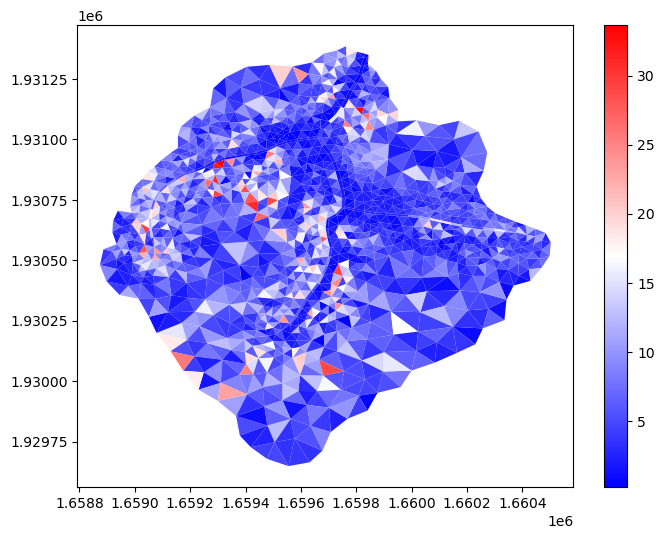

In [63]:

if ELM_SOILCOLUMN:
#--- dz structure from ELM soil column
    zi_soil, dzs_soil, z_soil = elm_domain.soilcolumn(more_vertlayers=MORE_VERTLAYERS, nlevgrnd=15)
    dzs_soil = dzs_soil[1:] # in ELM, layer indexing from 1. So need to do something here.
    z_soil = z_soil[1:]
    total_thickness = sum(dzs_soil)
    print('ELM soil column total thickness: ', sum(dzs_soil))

    # no geolayer needed because ELM soil column thickness of ~42 m
    dzs_geo = np.empty(0)

#--- generate ELM domain.nc, unstructureed, from m2 surface mesh
    elmdomain = {}

    ngrid = m2.num_cells
    print('ELM surface grid number: ', ngrid)
    m2_crs = str(m2.crs)
    if m2.crs.is_projected:
        # need to transform proj to lat/lon
        elm_crs = watershed_workflow.crs.latlon_crs
        x = m2.centroids[:, 0]
        y = m2.centroids[:, 1]
        elmdomain['xc'], elmdomain['yc'] = \
            watershed_workflow.warp.xy(x, y, m2.crs, elm_crs)

    else:
        elmdomain['xc'] = m2.centroids[:,0]
        elmdomain['yc'] = m2.centroids[:,1]
    elmdomain['zc'] = m2.centroids[:,2]

    nv = len(m2.conn[0])
    elmdomain['xv'] = np.empty((ngrid,nv)); elmdomain['xv'][...]=np.nan
    elmdomain['yv'] = np.empty((ngrid,nv)); elmdomain['yv'][...]=np.nan
    elmdomain['zv'] = np.empty((ngrid,nv)); elmdomain['zv'][...]=np.nan
    #elmdomain['area'] = np.empty(ngrid)  # need to be in arc-radian^2
    elmdomain['area_km2'] = np.empty(ngrid)
    for j in range(ngrid):
        if river_mask[j]==1.0: continue

        if m2.crs.is_projected:
            elm_crs = watershed_workflow.crs.latlon_crs

            x = m2.coords[m2.conn[j][:]][:,0]
            y = m2.coords[m2.conn[j][:]][:,1]
            lon, lat = watershed_workflow.warp.xy(x, y, m2.crs, elm_crs)
            elmdomain['xv'][j,:] = lon
            elmdomain['yv'][j,:] = lat
        else:
            elmdomain['xv'][j,:] = m2.coords[m2.conn[j][:]][:,0]
            elmdomain['yv'][j,:] = m2.coords[m2.conn[j][:]][:,1]
        vert3 = m2.coords[m2.conn[j][:]][:,0:2]
        area_xy = watershed_workflow.utils.computeTriangleArea(*vert3)
        elmdomain['area_km2'][j] = area_xy*1.0e-6

        elmdomain['zv'][j,:] = m2.coords[m2.conn[j][:]][:,2]

    elmdomain['mask'] = np.ones(ngrid) # land mask always 1 now, but cautious near coastal region
    elmdomain['mask'][np.where(river_mask==1.0)] = 0 # mask out river or water-body temporarily
    elmdomain['frac'] = np.ones(ngrid)
    elmdomain['frac'][np.where(river_mask==1.0)] = 0

    elmdomain['crs']=m2.crs

    ncf_domain = 'domain.lnd.'+str(ngrid)+'x1pt.'+myname+'.nc'
    output_filenames['elmdomain'] = toOutput(f'{ncf_domain}')
    try:
        os.remove(output_filenames['elmdomain'])
    except FileNotFoundError:
        pass

    elm_domain.domain_ncwrite(elmdomain, WRITE2D=False, ncfile=output_filenames['elmdomain'], coord_system=False)

    # extracting and re-distributing ELM surfdata*.nc, according to new domain.nc
    # (CAN do offline)
    ncsrf0 = 'surfdata_0.5x0.5_simyr1850_c240308_TOP.nc' # this will be from E3SM inputdata server or local
    #ncflu0 = None
    ncflu0 = 'landuse.timeseries_0.5x0.5_hist_simyr1850-2015_c240308.nc'

    allsurf = elm_domain.refine_surfdata(outdir=work_dir, \
                    lnd_domain_file='../domain.lnd.r05_RRSwISC6to18E3r5.240328.nc', \
                    fsurdat=ncsrf0, \
                    flanduse_timeseries=ncflu0, \
                    userdomain=output_filenames['elmdomain'])

    # updating ELM surfdata*.nc, unstructureed, from m2 surface cell_data, if any
    ncfin = allsurf[0]
    ncf_surf = 'surfdata_'+str(ngrid)+'x1pt_simyr1850_'+myname+'.nc'
    output_filenames['elmsurfdata'] = toOutput(f'{ncf_surf}')
    if ncflu0 != None:
        ncfin1 = allsurf[1]
        ncf_surf1 = 'landuse.timeseries_'+str(ngrid)+'x1pt_hist_simyr1850-2015_'+myname+'.nc'
        output_filenames['elmlutimeseries'] = toOutput(f'{ncf_surf1}')

    surf_from_atsm2 = {}
    surf_from_atsm2['LATIXY'] = elmdomain['yc']
    surf_from_atsm2['LONGXY'] = elmdomain['xc']

    # surfdata to be put into
    surf_vars = ''
    nlevsoi = 10

    # from ATS
    surf_vars+='TOPO'
    surf_from_atsm2['TOPO'] = m2.centroids[:,2]   # elevation

    topo_raster = os.path.join(data_dir,'topography','basin_slope.tif')
    if os.path.exists(topo_raster):
        topo = watershed_workflow.sources.ManagerRaster(topo_raster). \
                getDataset(watershed.exterior.buffer(10), watershed.crs)['band_1']
        m2.cell_data['SLOPE'] = watershed_workflow.getDatasetOnMesh(m2, topo, method='linear')
        surf_vars+=',SLOPE'
        surf_from_atsm2['SLOPE'] = m2.cell_data['SLOPE'].to_numpy()

    topo_raster = os.path.join(data_dir,'topography','basin_aspect.tif')
    if os.path.exists(topo_raster):
        topo = watershed_workflow.sources.ManagerRaster(topo_raster). \
                getDataset(watershed.exterior.buffer(10), watershed.crs)['band_1']
        m2.cell_data['ASPECT'] = watershed_workflow.getDatasetOnMesh(m2, topo, method='linear')

        if 'SLOPE' in m2.cell_data.keys():
            surf_vars+=',SINSL_SINAS' #sin(SLOPE)*sin(ASPECT) 
            surf_from_atsm2['SINSL_SINAS'] = np.sin(m2.cell_data['SLOPE'].to_numpy())* \
                                            np.sin(m2.cell_data['ASPECT'].to_numpy())
            surf_vars+=',SINSL_COSAS' #sin(SLOPE)*cos(ASPECT) 
            surf_from_atsm2['SINSL_COSAS'] = np.sin(m2.cell_data['SLOPE'].to_numpy())* \
                                            np.cos(m2.cell_data['ASPECT'].to_numpy())


    topo_raster = os.path.join(data_dir,'topography','basin_skyview.tif') 
    if os.path.exists(topo_raster):
        topo = watershed_workflow.sources.ManagerRaster(topo_raster). \
                getDataset(watershed.exterior.buffer(10), watershed.crs)['band_1']
        m2.cell_data['SKY_VIEW'] = watershed_workflow.getDatasetOnMesh(m2, topo, method='linear')
        surf_vars+=',SKY_VIEW'
        surf_from_atsm2['SKY_VIEW'] = m2.cell_data['SKY_VIEW'].to_numpy()

    #
    #TERRAIN_CONFIG: may be estimated, according to Lee et al. (2011) (Eq. (4)), as following: 
    # (1+cos(slope))/2-SKYVIEW
    # Wei-Liang Lee, K.N. Liou, and Alex Hall, 2011. Parameterization of solar fluxes over mountain surfaces for application to climate models. JGR,116, D01101
    if 'SLOPE' in m2.cell_data.keys() and \
        'SKY_VIEW' in m2.cell_data.keys():
        m2.cell_data['TERRAIN_CONFIG'] = \
            (1.0+np.cos(m2.cell_data['SLOPE'].to_numpy()))/2.0 \
            - m2.cell_data['SKY_VIEW'].to_numpy()
        surf_vars+=',TERRAIN_CONFIG'
        surf_from_atsm2['TERRAIN_CONFIG'] = m2.cell_data['TERRAIN_CONFIG'].to_numpy()

    # looks like ATS not really have layered properties of soil
    # to be consistent, ELM should be in a similar way
    znodes = m2.cell_data['thickness [m]'].to_numpy()
    zdata = m2.cell_data['total sand pct [%]'].to_numpy()
    temp_data = np.zeros((nlevsoi, ngrid))
    for ig in range(ngrid):
        temp_data[:,ig] = \
            elm_mksrfdata.mksrfdata_soilcolumn_interp( \
                        srf_soildata=zdata[ig], \
                        srf_soilnode=znodes[ig], \
                        nlevsoi = nlevsoi, fill_method="extrapolate")
    surf_vars+=',PCT_SAND'
    surf_from_atsm2['PCT_SAND'] = temp_data

    zdata = m2.cell_data['total clay pct [%]'].to_numpy()
    temp_data = np.zeros((nlevsoi, ngrid))
    for ig in range(ngrid):
        temp_data[:,ig] = \
            elm_mksrfdata.mksrfdata_soilcolumn_interp( \
                        srf_soildata=zdata[ig], \
                        srf_soilnode=znodes[ig], \
                        nlevsoi = nlevsoi, fill_method="extrapolate")
    surf_vars+=',PCT_CLAY'
    surf_from_atsm2['PCT_CLAY'] = temp_data

    # from SoilGrids v2.0.1
    soilgrids_dir = os.path.join(data_dir,'soil_structure','soilgrids')
    os.makedirs(soilgrids_dir, exist_ok=True)
    xlmt = elmdomain['xv'].flatten()
    xrange = [np.nanmin(xlmt), np.nanmax(xlmt)]
    ylmt = elmdomain['yv'].flatten()
    yrange = [np.nanmin(ylmt), np.nanmax(ylmt)]

    #soilvars=['ocd','bdod','sand','silt','clay'] #unit: hg/m3-->0.1kg/m3, cg/cm3 -->0.01kg/dm3, %, %, %
    soilvars=['ocd'] #unit: hg/m3 --> 0.1kg/m3 ORGANIC in ELM, but not sure if in kgC or kgSOM ???
    horizons = ['0-5cm','5-15cm','15-30cm','30-60cm','60-100cm','100-200cm']
    elm_mksrfdata.download_geotiff_soilgrids( \
            Range_XLONG=xrange, Range_YLATI=yrange, \
            outputpath=soilgrids_dir, \
            soilvars=soilvars, \
            value='mean')
    #
    vardata = {}
    for ivar in soilvars:
        temp_data = np.empty((len(horizons), ngrid))
        for iz in range(len(horizons)):
            zstr=horizons[iz]
            svar_horizon_id = ivar+'_'+zstr+'_mean'
            svar_horizon_value_tif = soilgrids_dir+'/'+svar_horizon_id+'.tif'
            svar = watershed_workflow.sources.ManagerRaster(svar_horizon_value_tif)
            svar2 = svar.getDataset(watershed.exterior, watershed.crs)['band_1']
            # map to the mesh
            m2.cell_data[svar_horizon_id] = watershed_workflow.getDatasetOnMesh(m2, svar2, method='linear')
            temp_data[iz,:] = m2.cell_data[svar_horizon_id].to_numpy()

        znodes = np.array([0.0, 0.025, 0.10, 0.225, 0.45, 0.80, 1.50, 2.0])  #mid-horizon + 2-ends (from top-bottom range of data interpolation)
        # ELM soil column data has 10 layers
        vardata[ivar] = np.empty((nlevsoi, ngrid))
        for ig in range(ngrid):
            zdata = np.concatenate(([temp_data[0,ig]],temp_data[:,ig],[temp_data[-1,ig]]))
            vardata[ivar][:,ig] = \
                elm_mksrfdata.mksrfdata_soilcolumn_interp( \
                        srf_soildata=zdata, \
                        srf_soilnode=znodes, \
                        nlevsoi=nlevsoi)

    #
    if 'ocd' in vardata.keys():
        surf_vars+=',ORGANIC'
        surf_from_atsm2['ORGANIC'] = vardata['ocd']*0.1 #but not sure if 'ocd' in kgC or kgSOM ???

    #
    # write all in 'surf_vars' to surfdata.nc
    print('usr-provided varables: ', surf_vars)
    elm_mksrfdata.mksrfdata_updatevals(ncfin, \
                        fsurfnc_out=output_filenames['elmsurfdata'], \
                        user_srf_data=surf_from_atsm2, \
                        user_srf_vars=surf_vars)


    # visualizing ELM data, as needed
    elmvar = 'SLOPE'
    if True:
        m2.cell_data[elmvar] = surf_from_atsm2[elmvar]

        # simply plotting
        elmvar_gons = m2.plot(facecolors=m2.cell_data[elmvar], cmap='bwr', edgecolors=None)
        plt.show()

    #


In [64]:
# layer extrusion
DTB = m2.cell_data['dtb'].values
soil_color = m2.cell_data['soil_color'].values
geo_color = m2.cell_data['geology_color'].values
soil_thickness = m2.cell_data['thickness [m]'].values


# -- data structures needed for extrusion
layer_types = []
layer_data = []
layer_ncells = []
layer_mat_ids = []

# -- soil layer --
depth = 0
for dz in dzs_soil:
    depth += 0.5 * dz
    layer_types.append('constant')
    layer_data.append(dz)
    layer_ncells.append(1)
    
    # use glhymps params
    br_or_geo = np.where(depth < DTB, geo_color, 999)
    soil_or_br_or_geo = np.where(np.bitwise_and(soil_color > 0, depth < soil_thickness),
                                 soil_color,
                                 br_or_geo)

    layer_mat_ids.append(soil_or_br_or_geo)
    depth += 0.5 * dz
    
# -- geologic layer --
for dz in dzs_geo:
    depth += 0.5 * dz
    layer_types.append('constant')
    layer_data.append(dz)
    layer_ncells.append(1)
    
    geo_or_br = np.where(depth < DTB, geo_color, 999)

    layer_mat_ids.append(geo_or_br)
    depth += 0.5 * dz

# print the summary
watershed_workflow.mesh.Mesh3D.summarizeExtrusion(layer_types, layer_data, 
                                            layer_ncells, layer_mat_ids)

# downselect subsurface properties to only those that are used
layer_mat_id_used = list(np.unique(np.array(layer_mat_ids)))
subsurface_props_used = subsurface_props.loc[layer_mat_id_used]
subsurface_props_used


2025-12-13 12:00:19,759 - root - INFO: Cell summary:
2025-12-13 12:00:19,759 - root - INFO: ------------------------------------------------------------
2025-12-13 12:00:19,760 - root - INFO: l_id	| c_id	|mat_id	| dz		| z_top
2025-12-13 12:00:19,760 - root - INFO: ------------------------------------------------------------
2025-12-13 12:00:19,760 - root - INFO:  00 	| 00 	| 1011 	|   0.017513 	|   0.000000
2025-12-13 12:00:19,760 - root - INFO:  01 	| 01 	| 1011 	|   0.027579 	|   0.017513
2025-12-13 12:00:19,760 - root - INFO:  02 	| 02 	| 1011 	|   0.045470 	|   0.045092
2025-12-13 12:00:19,761 - root - INFO:  03 	| 03 	| 1011 	|   0.074967 	|   0.090562
2025-12-13 12:00:19,761 - root - INFO:  04 	| 04 	| 1011 	|   0.123600 	|   0.165529
2025-12-13 12:00:19,761 - root - INFO:  05 	| 05 	| 1011 	|   0.203783 	|   0.289130
2025-12-13 12:00:19,761 - root - INFO:  06 	| 06 	| 1011 	|   0.335981 	|   0.492912
2025-12-13 12:00:19,761 - root - INFO:  07 	| 07 	| 1011 	|   0.553938 	|   0.8

,ID,name,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],geometry,mukey,thickness [m],bulk density [g/cm^3],total sand pct [%],total silt pct [%],total clay pct [%]
100,"(922315,)",GLHYMPS-922315,GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,"MULTIPOLYGON (((1661665.546 1893067.866, 16615...",NaN,NaN,NaN,NaN,NaN,NaN
101,"(922332,)",GLHYMPS-922332,GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,"POLYGON ((1656069.303 1936812.195, 1656135.688...",NaN,NaN,NaN,NaN,NaN,NaN
102,"(922379,)",GLHYMPS-922379,GLHYMPS,1.258925e-11,0.280000,0.001000,2.000000,0.010000,"MULTIPOLYGON (((1662145.566 1919512.522, 16620...",NaN,NaN,NaN,NaN,NaN,NaN
999,999,bedrock,n/a,1.000000e-16,0.050000,0.000019,3.000000,0.010000,None,NaN,NaN,NaN,NaN,NaN,NaN
1000,137713,NRCS-137713,NRCS,7.763941e-13,0.461420,0.000089,1.417257,0.201758,"MULTIPOLYGON (((1659065.115 1929561.676, 16590...",137713.0,1.812500,1.427093,47.158057,35.713708,17.128235
1001,137737,NRCS-137737,NRCS,1.121346e-12,0.453628,0.000158,1.445159,0.196063,"MULTIPOLYGON (((1660563.272 1929931.566, 16605...",137737.0,1.947500,1.447885,68.198355,14.572973,17.228671
1002,137738,NRCS-137738,NRCS,1.164453e-12,0.453942,0.000158,1.445741,0.195702,"MULTIPOLYGON (((1659750.771 1929944.367, 16597...",137738.0,1.953684,1.447054,68.156365,14.703619,17.140016
1003,137788,NRCS-137788,NRCS,1.231552e-12,0.421756,0.000145,1.391674,0.210305,"MULTIPOLYGON (((1659189.97 1929588.567, 165920...",137788.0,1.810000,1.532347,62.425448,18.905372,18.669180
1004,137789,NRCS-137789,NRCS,1.171899e-12,0.431732,0.000134,1.382418,0.213728,"MULTIPOLYGON (((1659541.471 1929770.567, 16595...",137789.0,1.820000,1.505910,59.480100,20.596129,19.923771
1005,137790,NRCS-137790,NRCS,9.747239e-13,0.430030,0.000121,1.385635,0.210308,"MULTIPOLYGON (((1659555.792 1929653.951, 16595...",137790.0,1.893000,1.510420,55.450119,26.052274,18.497607


In [65]:
# extrude
m3 = watershed_workflow.mesh.Mesh3D.extruded_Mesh2D(m2, layer_types, layer_data, 
                                             layer_ncells, layer_mat_ids)

In [66]:
print('2D labeled sets')
print('---------------')
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D labeled sets')
print('------------------------')
for ls in m3.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D side sets')
print('---------------------')
for ls in m3.side_sets:
    print(f'{ls.setid} : FACE : {len(ls.cell_list)} : "{ls.name}"')
    

2D labeled sets
---------------
10000 : CELL : 1895 : "0"
10001 : CELL : 1895 : "0 surface"
10002 : FACE : 86 : "0 boundary"
10003 : FACE : 14 : "0 outlet"
10004 : FACE : 13 : "surface domain outlet"
10005 : CELL : 72 : "river corridor 0 surface"
10006 : CELL : 19 : "stream order 2"
10007 : CELL : 53 : "stream order 1"
11 : CELL : 1 : "Open Water"
21 : CELL : 62 : "Developed, Open Space"
22 : CELL : 13 : "Developed, Low Intensity"
41 : CELL : 1205 : "Deciduous Forest"
43 : CELL : 69 : "Mixed Forest"
52 : CELL : 13 : "Shrub/Scrub"
81 : CELL : 188 : "Pasture/Hay"
82 : CELL : 152 : "Cultivated Crops"
90 : CELL : 191 : "Woody Wetlands"
95 : CELL : 2 : "Emergent Herbaceous Wetlands"

Extruded 3D labeled sets
------------------------
10000 : CELL : 28425 : "0"

Extruded 3D side sets
---------------------
1 : FACE : 1896 : "bottom"
2 : FACE : 1896 : "surface"
3 : FACE : 1275 : "external sides"
10001 : FACE : 1895 : "0 surface"
10002 : FACE : 1290 : "0 boundary"
10003 : FACE : 210 : "0 outlet"

In [67]:
# save the mesh to disk
output_filenames['mesh'] = toOutput(f'{myname}.exo')
try:
    os.remove(output_filenames['mesh'])
except FileNotFoundError:
    pass
m3.writeExodus(output_filenames['mesh'])

2025-12-13 12:00:23,376 - root - INFO: adding side set: 1
2025-12-13 12:00:23,381 - root - INFO: adding side set: 2
2025-12-13 12:00:23,383 - root - INFO: adding side set: 3
2025-12-13 12:00:23,385 - root - INFO: adding side set: 10001
2025-12-13 12:00:23,388 - root - INFO: adding side set: 10002
2025-12-13 12:00:23,390 - root - INFO: adding side set: 10003
2025-12-13 12:00:23,391 - root - INFO: adding side set: 10004
2025-12-13 12:00:23,393 - root - INFO: adding side set: 10005
2025-12-13 12:00:23,394 - root - INFO: adding side set: 10006
2025-12-13 12:00:23,396 - root - INFO: adding side set: 10007
2025-12-13 12:00:23,397 - root - INFO: adding side set: 11
2025-12-13 12:00:23,398 - root - INFO: adding side set: 21
2025-12-13 12:00:23,400 - root - INFO: adding side set: 22
2025-12-13 12:00:23,401 - root - INFO: adding side set: 41
2025-12-13 12:00:23,404 - root - INFO: adding side set: 43
2025-12-13 12:00:23,405 - root - INFO: adding side set: 52
2025-12-13 12:00:23,407 - root - INFO:


You are using exodus.py v 1.21.6 (seacas-py3), a python wrapper of some of the exodus library.

Copyright (c) 2013-2023 National Technology &
Engineering Solutions of Sandia, LLC (NTESS).  Under the terms of
Contract DE-NA0003525 with NTESS, the U.S. Government retains certain
rights in this software.

Opening exodus file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm.exo
Closing exodus file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm.exo


## Meteorological forcing dataset

In [68]:
# download the data -- note it is hourly!
met_data_raw = sources['meteorology'].getDataset(watershed.exterior.buffer(500), crs, start_leap, end_leap)

# convert it to daily mean immediately
met_data_raw_daily = met_data_raw.resample(time=datetime.timedelta(hours=24)).mean()

# also, note that we sampled from 8/1 to 8/1, meaning we have an extra day now.
met_data_raw_daily = met_data_raw_daily.isel({'time' : slice(0, -1)})
print(f'Total days: {len(met_data_raw_daily['time'])}')


2025-12-13 12:01:04,856 - root - INFO: Incoming shape area = 0.000519293454958574
2025-12-13 12:01:04,856 - root - INFO: ... buffering incoming shape by = 0.00833333
2025-12-13 12:01:04,856 - root - INFO: ... buffered shape area = 0.0014329060529469334
2025-12-13 12:01:04,857 - root - INFO:   Using existing: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/meteorology/aorc/aorc_2003-2022_38.8884x-76.5328-38.8481x-76.5799.nc


Total days: 6940


In [69]:
# AORC is a non-projected dataset in lat-lon
# warp it to projected
met_data_warped = watershed_workflow.warp.dataset(met_data_raw_daily, crs, 'bilinear')

# convert and write ATS format for transient run
met_data_transient = watershed_workflow.meteorology.convertAORCToATS(met_data_warped)
met_data_transient


2025-12-13 12:01:14,454 - root - INFO: Converting AORC to ATS met input


<xarray.Dataset> Size: 19MB
Dimensions:                                (x: 6, y: 7, time: 6940)
Coordinates:
  * x                                      (x) float64 48B 1.658e+06 ... 1.66...
  * y                                      (y) float64 56B 1.933e+06 ... 1.92...
  * time                                   (time) object 56kB 2003-01-01 00:0...
    spatial_ref                            int64 8B 0
Data variables:
    air temperature [K]                    (time, y, x) float64 2MB nan ... nan
    incoming shortwave radiation [W m^-2]  (time, y, x) float64 2MB nan ... nan
    incoming longwave radiation [W m^-2]   (time, y, x) float64 2MB nan ... nan
    vapor pressure air [Pa]                (time, y, x) float64 2MB nan ... nan
    wind speed [m s^-1]                    (time, y, x) float64 2MB nan ... nan
    precipitation total [m s^-1]           (time, y, x) float64 2MB nan ... nan
    precipitation rain [m s^-1]            (time, y, x) float64 2MB 0.0 ... 0.0
    precipitation snow [m SWE s^-1]        (time, y, x) float64 2MB 0.0 ... 0.0
Attributes:
    name:                             AORC v1.1
    source:                           NOAA AWS S3 Zarr
    wind speed reference height [m]:  10.0

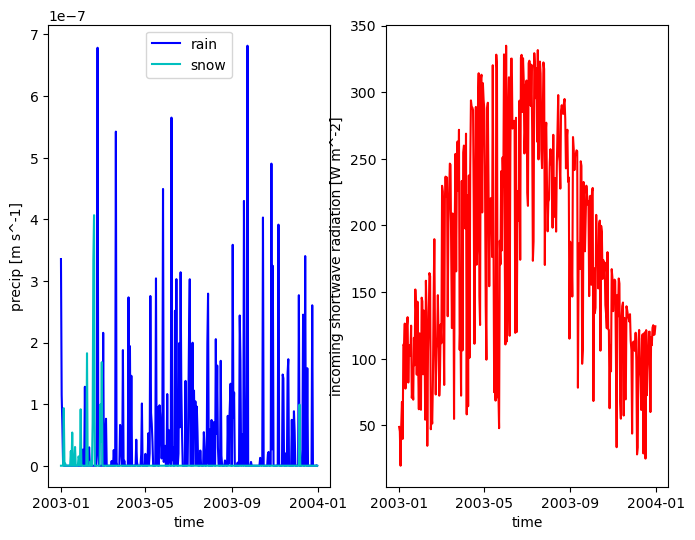

In [70]:
# plot a few of the met data -- does it look reasonable?
def plotMetData(met, x=1, y=4):
    """plot one pixel as a function of time"""
    fig = plt.figure()
    ax = fig.add_subplot(121)
    
    met_data_single_pixel = met.isel({'time':slice(0,365),
                                               'x' : x,
                                               'y' : y})
    
    met_data_single_pixel['precipitation rain [m s^-1]'].plot(color='b', label='rain')
    met_data_single_pixel['precipitation snow [m SWE s^-1]'].plot(color='c', label='snow')
    ax.set_ylabel('precip [m s^-1]')
    ax.set_title('')
    ax.legend()
    
    ax = fig.add_subplot(122)
    met_data_single_pixel['incoming shortwave radiation [W m^-2]'].plot(color='r', label='qSW_in')
    ax.set_ylabel('incoming shortwave radiation [W m^-2]')
    ax.set_title('')
    
    plt.show()

plotMetData(met_data_transient)

In [71]:
# write transient data to disk
filename = toOutput(f'{myname}_aorc-{start.year}-{end.year}.h5')
output_filenames['meteorology_transient'] = filename
watershed_workflow.io.writeDatasetToHDF5(
    filename,
    met_data_transient
    )

2025-12-13 12:01:22,130 - root - INFO: Writing HDF5 file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm_aorc-2003-2022.h5


In [72]:
# compute the typical year
# note that we have to do this only on no-leap data to line up the days
#
# also, we do this on the original variables and then re-compute ATS quantities
ndays = met_data_warped['APCP_surface'].shape[0]
print('nyears = ', ndays // 365)
print('n days leftover = ', ndays % 365)
print('note, that leftover day(s) are leap day(s).')


nyears =  19
n days leftover =  5
note, that leftover day(s) are leap day(s).


In [73]:
# cannot compute a typical year for leap year -- need to align days-of-the-year
# remove leap day (Dec 31 of leap years)
met_data_noleap = watershed_workflow.data.filterLeapDay(met_data_warped)
met_data_noleap

# then compute a "typical" year
met_data_typical = watershed_workflow.data.computeAverageYear(met_data_noleap, (start - steadystate_td), nyears_cyclic_steadystate)

# and lastly convert to ATS
met_data_typical_ats = watershed_workflow.meteorology.convertAORCToATS(met_data_typical)

2025-12-13 12:01:30,106 - root - INFO: Converting AORC to ATS met input


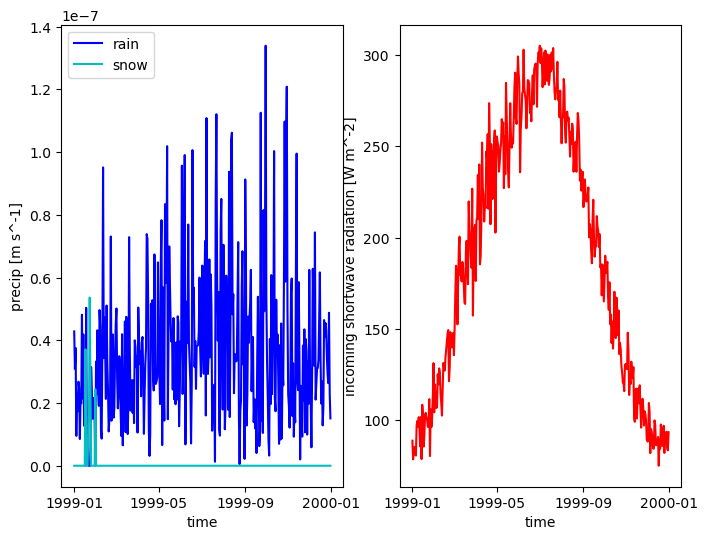

In [74]:
# plot a few of the met data -- does it look reasonable?
plotMetData(met_data_typical_ats)

In [75]:
# write cyclic steadystate data to disk
filename = toOutput(f'{myname}_daymet-CyclicSteadystate.h5')
output_filenames['meteorology_cyclic_steadystate'] = filename
watershed_workflow.io.writeDatasetToHDF5(
    filename,
    met_data_typical_ats,
    met_data_typical_ats.attrs)


2025-12-13 12:01:32,351 - root - INFO: Writing HDF5 file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/output_data/gcrew-atselm_daymet-CyclicSteadystate.h5


In [76]:
# compute the average precip rate for steadystate solution
precip_mean = (met_data_transient['precipitation rain [m s^-1]'].data + met_data_transient['precipitation snow [m SWE s^-1]'].data).mean()
logging.info(f'Mean precip value = {precip_mean}')


2025-12-13 12:01:36,181 - root - INFO: Mean precip value = 2.5572994919078494e-08


In [77]:
# hourly dataset generation as ELM-ready format
if ELM_SOILCOLUMN:
    # standard ELM met. variables
    elmvnames=['LONGXY','LATIXY','time', 'start_year', 'end_year', \
            'ZBOT','TBOT', 'PRECTmms', 'QBOT', 'FSDS', 'FLDS', 'PSRF', 'WIND']

    elmmet={}
    met_noleap = watershed_workflow.data.filterLeapDay(met_data_raw)

    y = met_noleap['latitude'].to_numpy()
    x = met_noleap['longitude'].to_numpy()
    elmmet['LONGXY'] = np.meshgrid(x,y)[0].flatten() # 2D -> 1D
    elmmet['LATIXY'] = np.meshgrid(x,y)[1].flatten() # 2D -> 1D

    #
    t = met_noleap['time'].to_numpy()
    t_yr0 = t[0].year
    t_unit = "days since "+str(t_yr0)+"-01-01 00:00:00" 
    t_dsyr0 = cftime.date2num(t, t_unit, calendar='noleap')
    elmmet['time'] = t_dsyr0
    elmmet['tunit'] = t_unit

    elmmet['TBOT'] = np.reshape(met_noleap['TMP_2maboveground'].to_numpy(),(t.size,x.size*y.size))
    elmmet['QBOT'] = np.reshape(met_noleap['SPFH_2maboveground'].to_numpy(),(t.size,x.size*y.size))
    elmmet['PRECTmms'] = np.reshape(met_noleap['APCP_surface'].to_numpy()/3600.0,(t.size,x.size*y.size))  # kg/m2/hour --> mm/s
    elmmet['FSDS'] = np.reshape(met_noleap['DSWRF_surface'].to_numpy(),(t.size,x.size*y.size))
    elmmet['FLDS'] = np.reshape(met_noleap['DLWRF_surface'].to_numpy(),(t.size,x.size*y.size))
    elmmet['PSRF'] = np.reshape(met_noleap['PRES_surface'].to_numpy(),(t.size,x.size*y.size))
    uw = np.reshape(met_noleap['UGRD_10maboveground'].to_numpy(),(t.size,x.size*y.size))
    uv = np.reshape(met_noleap['VGRD_10maboveground'].to_numpy(),(t.size,x.size*y.size)) 
    elmmet['WIND'] = np.sqrt(uw*uw + uv*uv)

    # save in ELM forcing data format
    #met_odir = data_dir+'/meteorology/cpl_bypass_full/'
    met_odir = toOutput(f'cpl_bypass_full/')
    output_filenames['meteorology_for_elm_dir'] = met_odir
    os.makedirs(met_odir, exist_ok=True)
    options_wrt = SimpleNamespace( \
            met_idir = data_dir+'/cpl_bypass_template/', \
            met_odir = met_odir, \
            nc_create = True, \
            nc_write = False, \
            nc_write_mettype = 'ATS-subdaily_cplbypass' )
    elm_metdata.elm_metdata_write(options_wrt, elmmet)

#


Create new ELM forcing data ?  True
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/cpl_bypass_template/ATS-subdaily_TBOT_z01.nc
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/cpl_bypass_template/ATS-subdaily_PRECTmms_z01.nc
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/cpl_bypass_template/ATS-subdaily_QBOT_z01.nc
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/cpl_bypass_template/ATS-subdaily_FSDS_z01.nc
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/cpl_bypass_template/ATS-subdaily_FLDS_z01.nc
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/GCREW/input_data/cpl_bypass_template/ATS-subdaily_PSRF_z01.nc
cpl_bypass template file: /Users/f9y/mygithub/ATS_REPOS/watershed-workflow/examples/

## Write ATS input files

Now we have the mesh file written and all of the forcing datasets (meteorology, LAI) written.  It remains to write ATS XML files that will be the runs.

There are three runs done:

- steadystate: forces a surface + subsurface only problem with constant, uniform precip until true steadystate
- cyclic steadystate: forces with a typical year of averaged data
- transient: runs with real daily data from start to end

In [78]:
# Note that each of these are defined as functions so we can reuse them for all three input files.

# add the subsurface and surface domains
#
# Note this also adds a "computational domain" region to the region list, and a vis spec 
# for "domain"
def add_domains(main_list, mesh, surface_region='surface', snow=True, canopy=True):
    ats_input_spec.public.add_domain(main_list, 
                                 domain_name='domain', 
                                 dimension=3, 
                                 mesh_type='read mesh file',
                                 mesh_args={'file':mesh})
    if surface_region:
        main_list['mesh']['domain']['build columns from set'] = surface_region    
    
        # Note this also adds a "surface domain" region to the region list and a vis spec for 
        # "surface"
        ats_input_spec.public.add_domain(main_list,
                                domain_name='surface',
                                dimension=2,
                                mesh_type='surface',
                                mesh_args={'surface sideset name':'surface'})
    if snow:
        # Add the snow and canopy domains, which are aliases to the surface
        ats_input_spec.public.add_domain(main_list,
                                domain_name='snow',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})
    if canopy:
        ats_input_spec.public.add_domain(main_list,
                                domain_name='canopy',
                                dimension=2,
                                mesh_type='aliased',
                                mesh_args={'target':'surface'})


In [79]:
def add_land_cover(main_list):
    # next write a land-cover section for each NLCD type
    for index, nlcd_name in zip(nlcd_indices, nlcd_labels):
        ats_input_spec.public.set_land_cover_default_constants(main_list, nlcd_name)

    land_cover_list = main_list['state']['model parameters']['land cover types']
    # update some defaults for
    # ['Other', 'Deciduous Forest']
    # note, these are from the CLM Technical Note v4.5
    #
    # Rooting depth curves from CLM TN 4.5 table 8.3
    #
    # Note, the mafic potential values are likely pretty bad for the types of van Genuchten 
    # curves we are using (ETC -- add paper citation about this topic).  Likely they need
    # to be modified.  Note that these values are in [mm] from CLM TN 4.5 table 8.1, so the 
    # factor of 10 converts to [Pa]
    #
    # Note, albedo of canopy taken from CLM TN 4.5 table 3.1
    land_cover_list['Deciduous Forest']['rooting profile alpha [-]'] = 6.0
    land_cover_list['Deciduous Forest']['rooting profile beta [-]'] = 2.0
    land_cover_list['Deciduous Forest']['rooting depth max [m]'] = 10.0
    land_cover_list['Deciduous Forest']['capillary pressure at fully closed stomata [Pa]'] = 224000
    land_cover_list['Deciduous Forest']['capillary pressure at fully open stomata [Pa]'] = 35000 * .10
    land_cover_list['Deciduous Forest']['albedo of canopy [-]'] = 0.1



In [80]:
# add soil sets: note we need a way to name the set, so we use, e.g. SSURGO-MUKEY.
def soil_set_name(ats_id):
    return subsurface_props_used.loc[ats_id, 'name']

def add_soil_properties(main_list):
    # add soil material ID regions, porosity, permeability, and WRMs
    for ats_id in subsurface_props_used.index:
        props = subsurface_props_used.loc[ats_id]
        set_name = soil_set_name(ats_id)
        
        if props['van Genuchten n [-]'] < 1.5:
            smoothing_interval = 0.01
        else:
            smoothing_interval = 0.0
        
        ats_input_spec.public.add_soil_type(main_list, set_name, ats_id, output_filenames['mesh'],
                                            float(props['porosity [-]']),
                                            float(props['permeability [m^2]']), 1.e-7,
                                            float(props['van Genuchten alpha [Pa^-1]']),
                                            float(props['van Genuchten n [-]']),
                                            float(props['residual saturation [-]']),
                                            float(smoothing_interval))    



In [81]:
# get an ATS "main" input spec list -- note, this is a dummy and is not used to write any files yet
def get_main(steadystate=False):
    main_list = ats_input_spec.public.get_main()

    # add the mesh and all domains
    mesh = os.path.join('..', output_filenames['mesh'])
    add_domains(main_list, mesh)

    # tell the partitioner to use our pre-partition from cell_data
    main_list['mesh']['domain']['partitioner'] = 'from exodus file'

    # add labeled sets
    for ls in m3.labeled_sets:
        ats_input_spec.public.add_region_labeled_set(main_list, ls.name, ls.setid, mesh, ls.entity)
    for ss in m3.side_sets:
        ats_input_spec.public.add_region_labeled_set(main_list, ss.name, ss.setid, mesh, 'FACE')

    # add land cover
    add_land_cover(main_list)

    # add soil properties
    add_soil_properties(main_list)

    # add observations for each subcatchment
    if steadystate:
        time_args = {'cycles start period stop':[0,10,-1],}
        obs = ats_input_spec.public.add_observation(main_list, "water_balance_computational_domain",
                                               "water_balance_computational_domain.csv", obs_args=time_args)
        obs_precip = ats_input_spec.public.add_observable(obs, 'water source [m^3 s^-1]', 'surface-precipitation', 'computational domain', 'integral', 'cell')
        obs_q = ats_input_spec.public.add_observable(obs, 'net runoff [mol s^-1]', 'surface-water_flux', 'computational domain boundary', 'extensive integral', 'face')
        obs_q['direction normalized flux'] = True

        obs_wc = ats_input_spec.public.add_observable(obs, 'subsurface water content [mol]', 'water_content', 'computational domain', 'extensive integral', 'cell')
        obs_wc = ats_input_spec.public.add_observable(obs, 'surface water content [mol]', 'surface-water_content', 'surface domain', 'extensive integral', 'cell')    

    else:
        ats_input_spec.public.add_observations_water_balance(main_list, "computational domain", 
                                                        "surface domain", "external sides")

    return main_list


In [82]:
def populate_basic_properties(xml, main_xml):
    """This function updates an xml object with the above properties for mesh, regions, soil props, and lc props"""
    # find and replace the mesh list
    xml.replace('mesh', asearch.child_by_name(main_xml, 'mesh'))

    # find and replace the regions list
    xml.replace('regions', asearch.child_by_name(main_xml, 'regions'))

    # update the observations list
    obs = next(i for (i,el) in enumerate(xml) if el.get('name') == 'observations')
    xml[obs] = asearch.child_by_name(main_xml, 'observations')

    # update all model parameters lists
    xml_parlist = asearch.find_path(xml, ['state', 'model parameters'], no_skip=True)
    for parlist in asearch.find_path(main_xml, ['state', 'model parameters'], no_skip=True):
        try:
            xml_parlist.replace(parlist.getName(), parlist)
        except aerrors.MissingXMLError:
            xml_parlist.append(parlist)

    # update all evaluator lists
    xml_elist = asearch.find_path(xml, ['state', 'evaluators'], no_skip=True)
    for elist in asearch.find_path(main_xml, ['state', 'evaluators'], no_skip=True):
        try:
            xml_elist.replace(elist.getName(), elist)
        except aerrors.MissingXMLError:
            xml_elist.append(elist)    
    
    # find and replace land cover
    mp_list = asearch.find_path(xml, ['state', 'model parameters'], no_skip=True)
    lc_list = asearch.find_path(main_xml, ['state', 'model parameters', 'land cover types'], no_skip=True)
    
    try:
        mp_list.replace('land cover types', lc_list)
    except aerrors.MissingXMLError:
        mp_list.append(lc_list)


For the first file, we load a spinup template and write the needed quantities into that file, saving it to the appropriate run directory.  Note there is no DayMet or land cover or LAI properties needed for this run.  The only property that is needed is the domain-averaged, mean annual rainfall rate.  We then take off some for ET (note too wet spins up faster than too dry, so don't take off too much...).

In [83]:
def write_spinup_steadystate(name, precip_mean, **kwargs):
    # create the main list
    main = get_main(steadystate=True)

    # set precip to 0.6 * the mean precip value
    precip = main['state']['evaluators'].append_empty('surface-precipitation')
    precip.set_type('independent variable constant', ats_input_spec.public.known_specs['evaluator-independent-variable-constant-spec'])
    precip['value'] = float(precip_mean * .6)

    
    # load the template file
    prefix = 'steadystate'
    xml = aio.fromFile(toInput(f'{prefix}-template.xml'))
    
    # update the template xml with the main xml generated here
    main_xml = ats_input_spec.io.to_xml(main)
    populate_basic_properties(xml, main_xml, **kwargs)

    # write to disk
    output_filenames[f'ats_xml_{prefix}'] = toWorkingDir(f'{name}-{prefix}.xml')
    filename = output_filenames[f'ats_xml_{prefix}']
    aio.toFile(xml, filename)

    # create a run directory
    output_filenames[f'ats_rundir_{prefix}'] = toWorkingDir(f'{name}-{prefix}')
    rundir = output_filenames[f'ats_rundir_{prefix}']
    os.makedirs(rundir, exist_ok=True)


For the second file, we load a transient run template.  This file needs the basics, plus DayMet and LAI as the "typical year data".  Also we set the run directory that will be used for the steadystate run.

For the third file, we load a transient run template as well.  This file needs the basics, DayMet with the actual data, and we choose for this run to use the MODIS typical year.  MODIS is only available for 2002 on, so if we didn't need 1980-2002 we could use the real data, but for this run we want a longer record.

In [84]:
def write_transient(name, cyclic_steadystate=False, **kwargs):
    # make a unique name based on options
    logging.info(f'Writing transient: {name}')

    if cyclic_steadystate:
        prefix = 'cyclic_steadystate'
        previous = 'steadystate'
    else:
        prefix = 'transient'
        previous = 'cyclic_steadystate'

    main = get_main()

    # add the DayMet evaluators
    if cyclic_steadystate:
        daymet_filename = output_filenames['meteorology_cyclic_steadystate']
    else:
        daymet_filename = output_filenames['meteorology_transient']
    ats_input_spec.public.add_daymet_box_evaluators(main, os.path.join('..', daymet_filename), True)

    # add the LAI filenames
    if cyclic_steadystate:
        lai_filename = output_filenames['nlcd_lai_cyclic_steadystate']
    else:
        lai_filename = output_filenames['nlcd_lai_transient']
    ats_input_spec.public.add_lai_point_evaluators(main, os.path.join('..', lai_filename), list(nlcd_labels_dict.values()))
    
    # load the template file
    template_filename = toInput(f'{prefix}-template.xml')
    xml = aio.fromFile(template_filename)

    # update the template xml with the main xml generated here
    main_xml = ats_input_spec.io.to_xml(main)
    populate_basic_properties(xml, main_xml, **kwargs)
    
    # update the start and end time -- would be nice to set these in main, but it would be 
    # confusing as to when to copy them in populate_basic_properties and when not to do so.
    start_day = 274
    if cyclic_steadystate:
        end_day = 274 + (nyears_cyclic_steadystate - 1) * 365 
    else:
        end_day = 274 + (end - start).days 
        
    par = asearch.find_path(xml, ['cycle driver', 'start time'])
    par.setValue(start_day)

    par = asearch.find_path(xml, ['cycle driver', 'end time'])
    par.setValue(end_day)
    
    # update the restart filenames
    for var in asearch.findall_path(xml, ['initial conditions', 'restart file']):
        var.setValue(os.path.join('..', output_filenames[f'ats_rundir_{previous}'], 'checkpoint_final.h5'))
   
    # write to disk and make a directory for running the run
    output_filenames[f'ats_xml_{prefix}'] = toWorkingDir(f'{name}-{prefix}.xml')
    filename = output_filenames[f'ats_xml_{prefix}']

    output_filenames[f'ats_rundir_{prefix}'] = toWorkingDir(f'{name}-{prefix}')
    rundir = output_filenames[f'ats_rundir_{prefix}']

    aio.toFile(xml, filename)
    os.makedirs(rundir, exist_ok=True)

In [85]:
write_spinup_steadystate(myname, precip_mean)
write_transient(myname, True)
write_transient(myname, False)

/Users/f9y/micromamba/amanzi-ats-tools/ats_input_spec/ats_input_spec/io.py:43: UserWarning: Creating an incomplete XML object, missing entries!
  warnings.warn('Creating an incomplete XML object, missing entries!')
2025-12-13 12:02:22,941 - root - INFO: Writing transient: gcrew-atselm
2025-12-13 12:02:22,957 - root - INFO: Writing transient: gcrew-atselm


## Completion and Summary

After this is complete, the following should work:

```
cd /path/to/ww/examples/Coweeta/Coweeta-steadystate
mpiexec -n 4 ats ../Coweeta-steadystate.xml &> out.log
cd ../Coweeta-cyclic_steadystate
mpiexec -n 4 ats ../Coweeta-cyclic_steadystate.xml &> out.log
cd ../Coweeta-transient
mpiexec -n 4 ats ../Coweeta-transient.xml &> out.log
```

In [86]:
# the following files were generated during this run:
print(f'{"role":<35}: filename')
print('-'*34, ': ', '-'*50)
for k,v in output_filenames.items():
    vs = list(splitPathFull(v))
    if vs[-2] == myname:
        v2 = vs[-1]
    else:
        v2 = os.path.join(vs[-2], vs[-1])
    
    print(f'{k:<35}: {v2}')

role                               : filename
---------------------------------- :  --------------------------------------------------
modis_lai_transient                : output_data/gcrew-atselm_LAI_MODIS_transient.h5
modis_lai_cyclic_steadystate       : output_data/gcrew-atselm_LAI_MODIS_CyclicSteadystate.h5
nlcd_lai_cyclic_steadystate        : output_data/gcrew-atselm_LAI_NLCD_CyclicSteadystate.h5
nlcd_lai_transient                 : output_data/gcrew-atselm_LAI_NLCD_2003_2022.h5
subsurface_properties              : output_data/gcrew-atselm_subsurface_properties.csv
elmdomain                          : output_data/domain.lnd.1896x1pt.gcrew-atselm.nc
elmsurfdata                        : output_data/surfdata_1896x1pt_simyr1850_gcrew-atselm.nc
elmlutimeseries                    : output_data/landuse.timeseries_1896x1pt_hist_simyr1850-2015_gcrew-atselm.nc
mesh                               : output_data/gcrew-atselm.exo
meteorology_transient              : output_data/gcrew-atselm_aorc

In [87]:
logging.info('this workflow is a total success!')

2025-12-13 12:02:30,524 - root - INFO: this workflow is a total success!


In [88]:
# double-checking correct centroid info
np.save('m3_bary_centroids.npy', m3.barycentric_centroids)